# Exploratory Data Analysis

This notebook is the “sanity-check” EDA layer for the cleaned election datasets. The goal is *not* to build a full model yet, but to make sure our merged data behaves the way we expect, and to surface any states or counties that look suspicious.

The workflow is: (1) load the processed per-state outputs for **2008 / 2016 / 2020**, (2) reduce each year to a consistent set of columns (DEM/REP totals + identifiers), (3) compute simple quantities like REP vote shares, and then (4) visualize how primary dynamics relate to general-election outcomes at both the **within-state** and **across-state** levels.


## 0. Libraries Import

We start by importing the standard packages we use throughout the analysis:  
- **pandas / numpy** for table operations and basic math,  
- **Path** for robust file paths (so the same code works on different machines), and  
- **matplotlib** for all plots in this notebook (percent formatting, legends, and label readability tricks).


In [11]:
import re
import glob
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from matplotlib.ticker import PercentFormatter
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe

## 1. Data Processing

In this section, we build one merged table per election year by stacking the cleaned state CSVs under `data/processed/<year>/`.  

A key design choice here is to keep the schema *simple and comparable*: we prioritize **DEM/REP totals** and a geographic identifier (county/precinct label). That avoids spending EDA time on third-party labels that vary a lot by state and by year, and it matches what we need later for “primary share vs general share” comparisons.


In [12]:
# Data path
DATA_DIR_2008 = Path("../../data/processed/2008")
DATA_DIR_2016 = Path("../../data/processed/2016")
DATA_DIR_2020 = Path("../../data/processed/2020")

### 1.1. 2008 Presidential Election

For 2008, we scan the `data/processed/2008/` folder, read every cleaned per-state CSV, and concatenate them into a single dataframe (`dt1`). The printout below tells us how many files were found and the resulting merged shape.

Because states can store party/candidate information differently, the merge step focuses on columns that look like **totals** plus a column that contains **county** (case-insensitive). After that, we explicitly subset to the columns and states that have the DEM/REP totals we need for the downstream share calculations.


In [13]:
# List every cleaned csv files in data/processed/2008
files = sorted(DATA_DIR_2008.rglob("*.csv"))
print(f"Found {len(files)} CSVs under {DATA_DIR_2008}")

# Iterate through and read in the csv files
frames = []
for f in files:
    # Peek header to decide which columns to load
    cols = pd.read_csv(f, nrows=0).columns
    
    # Identify the columns to keep
    county_col = [c for c in cols if re.search(r"county", str(c), re.IGNORECASE)]
    total_cols = [c for c in cols if "total" in str(c).lower()] 
    keep = county_col + total_cols
    if not keep:
        pass

    # Read in the file
    dt = pd.read_csv(f, usecols=keep)

    # Coerce "total" columns to numeric
    for c in total_cols:
        dt[c] = pd.to_numeric(dt[c].astype(str).str.replace(",", ""), errors="coerce")
        
    # Add state metadata
    dt.insert(0, "state", f.parent.name)

    # Append this to frame
    frames.append(dt)

# Sanity check    
print(f"Loaded {len(frames)} files in total.")

# Concatenate it into a merged clean csv
dt1 = pd.concat(frames, ignore_index=True, sort=False)
print("Merged shape:", dt1.shape)

# Sneak peek of the combined dataset
dt1.head(20)

Found 31 CSVs under ../../data/processed/2008
Loaded 31 files in total.
Merged shape: (1801, 42)


,state,county,rep_general_total,dem_general_total,lib_general_total,cst_general_total,grn_general_total,ind_general_total,psl_general_total,rep_primary_total,...,nlp_general_total,ust_general_total,npa_general_total,ref_general_total,pop_general_total,pro_general_total,pet_general_total,non_general_total,slp_general_total,wgr_general_total
0,AR,Arkansas County,2470.0,1338.0,19.0,39.0,12.0,98.0,6.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AR,Ashley County,4268.0,2976.0,39.0,38.0,54.0,112.0,17.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AR,Baxter County,6761.0,3296.0,125.0,96.0,75.0,278.0,16.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AR,Benton County,29052.0,23331.0,417.0,318.0,143.0,706.0,34.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AR,Boone County,4966.0,1917.0,94.0,81.0,63.0,209.0,17.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,AR,Bradley County,2262.0,1680.0,11.0,17.0,27.0,32.0,12.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,AR,Calhoun County,1462.0,691.0,14.0,8.0,6.0,29.0,7.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,AR,Carroll County,4043.0,2220.0,76.0,53.0,58.0,131.0,6.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,AR,Chicot County,2119.0,3043.0,13.0,2.0,7.0,24.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,AR,Clark County,2975.0,2269.0,31.0,33.0,29.0,116.0,10.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Since there are different parties represent in each state, this merged dataset might not be a good idea. Also, since we read every and all files in the `data/processed/2008` directory, there are states that don't have a complete data on the 2008 presidential (primary or general) election data. 

In [14]:
# Create a subset of dt where we only keep data related to DEM and REP, and only with state whose has complete data
keep_states_1 = ["AZ", "DE", "GA", "ID", "IL", "IN", "LA", "MA", "MT", "OH", "OR", "PA", "TN", "TX", "WI"]
keep_cols_1   = ["state", "county", "rep_general_total", "dem_general_total", "rep_primary_total", "dem_primary_total"]

# Keep only appropriate column
dt1_subset = dt1[keep_cols_1]

# Keep only complete states
dt1_subset = dt1_subset.loc[
    dt1_subset["state"].isin(keep_states_1)
]

# Peek of the subset of our merged dataframe
dt1_subset.head(20)

,state,county,rep_general_total,dem_general_total,rep_primary_total,dem_primary_total
75,AZ,Apache,8551.0,15390.0,2361.0,6481.0
76,AZ,Cochise,29026.0,18943.0,10699.0,9393.0
77,AZ,Coconino,22186.0,31433.0,8281.0,12050.0
78,AZ,Gila,14095.0,7884.0,6046.0,5852.0
79,AZ,Graham,8376.0,3487.0,2801.0,2244.0
80,AZ,Greenlee,1712.0,1165.0,368.0,1142.0
81,AZ,La Paz,3509.0,1929.0,1332.0,1041.0
82,AZ,Maricopa,746448.0,602166.0,350246.0,253985.0
83,AZ,Mohave,44333.0,22092.0,17511.0,10679.0
84,AZ,Navajo,19761.0,15579.0,7579.0,7472.0


With a “clean” subset in hand, we compute two key EDA variables:

- **REP primary share**: REP primary votes divided by (REP + DEM) primary votes  
- **REP general share**: REP general votes divided by (REP + DEM) general votes  

These shares let us compare counties on the same 0–1 scale even if the raw vote totals differ drastically. We also compute total votes for each election (primary and general) so later plots can use vote totals as weights or bubble sizes.

In [15]:
# Add REP vote share for primary and general
dt1_subset["rep_primary_share"] = dt1_subset["rep_primary_total"] / (dt1_subset["dem_primary_total"] + dt1_subset["rep_primary_total"])
dt1_subset["rep_general_share"] = dt1_subset["rep_general_total"] / (dt1_subset["dem_general_total"] + dt1_subset["rep_general_total"])

# Peek of the subset of our updated dataframe
dt1_subset.head(20)

,state,county,rep_general_total,dem_general_total,rep_primary_total,dem_primary_total,rep_primary_share,rep_general_share
75,AZ,Apache,8551.0,15390.0,2361.0,6481.0,0.267021,0.357170
76,AZ,Cochise,29026.0,18943.0,10699.0,9393.0,0.532500,0.605099
77,AZ,Coconino,22186.0,31433.0,8281.0,12050.0,0.407309,0.413771
78,AZ,Gila,14095.0,7884.0,6046.0,5852.0,0.508153,0.641294
79,AZ,Graham,8376.0,3487.0,2801.0,2244.0,0.555203,0.706061
80,AZ,Greenlee,1712.0,1165.0,368.0,1142.0,0.243709,0.595064
81,AZ,La Paz,3509.0,1929.0,1332.0,1041.0,0.561315,0.645274
82,AZ,Maricopa,746448.0,602166.0,350246.0,253985.0,0.579656,0.553493
83,AZ,Mohave,44333.0,22092.0,17511.0,10679.0,0.621178,0.667414
84,AZ,Navajo,19761.0,15579.0,7579.0,7472.0,0.503555,0.559168


In [16]:
# Add primary_total_votes and general_total_votes column
dt1_subset["primary_total_votes"] = dt1_subset["dem_primary_total"] + dt1_subset["rep_primary_total"]
dt1_subset["general_total_votes"] = dt1_subset["dem_general_total"] + dt1_subset["rep_general_total"]

# Peek of the subset of our updated dataframe
dt1_subset.head(20)

,state,county,rep_general_total,dem_general_total,rep_primary_total,dem_primary_total,rep_primary_share,rep_general_share,primary_total_votes,general_total_votes
75,AZ,Apache,8551.0,15390.0,2361.0,6481.0,0.267021,0.357170,8842.0,23941.0
76,AZ,Cochise,29026.0,18943.0,10699.0,9393.0,0.532500,0.605099,20092.0,47969.0
77,AZ,Coconino,22186.0,31433.0,8281.0,12050.0,0.407309,0.413771,20331.0,53619.0
78,AZ,Gila,14095.0,7884.0,6046.0,5852.0,0.508153,0.641294,11898.0,21979.0
79,AZ,Graham,8376.0,3487.0,2801.0,2244.0,0.555203,0.706061,5045.0,11863.0
80,AZ,Greenlee,1712.0,1165.0,368.0,1142.0,0.243709,0.595064,1510.0,2877.0
81,AZ,La Paz,3509.0,1929.0,1332.0,1041.0,0.561315,0.645274,2373.0,5438.0
82,AZ,Maricopa,746448.0,602166.0,350246.0,253985.0,0.579656,0.553493,604231.0,1348614.0
83,AZ,Mohave,44333.0,22092.0,17511.0,10679.0,0.621178,0.667414,28190.0,66425.0
84,AZ,Navajo,19761.0,15579.0,7579.0,7472.0,0.503555,0.559168,15051.0,35340.0


In [17]:
# Export merged csv file for future convenience
MERGED_2008 = DATA_DIR_2008 / "merged.csv"
MERGED_2008.parent.mkdir(parents=True, exist_ok=True)
dt1_subset.to_csv(MERGED_2008, index=False)
print(f"Saved merged dataset to: {MERGED_2008.resolve()}")

Saved merged dataset to: /Users/amourtu1934/Documents/1. Denison/5. Fall '25/Voter Turnout Modeling/analyze-voter-turnout/data/processed/2008/merged.csv


### 1.2. 2016 Presidential Election

For 2016, we repeat the same “read → merge → standardize → compute shares” pattern. The merged dataframe here is much larger (many more rows/columns), so schema consistency becomes even more important.

The main complication is that a subset of states do not ship clean `dem_*_total` / `rep_*_total` columns directly. For those states, we reconstruct totals by summing candidate-level columns (e.g., `gen_rep_*`, `gen_dem_*`) so we can still compute comparable DEM/REP shares.


In [19]:
# List every cleaned csv files in data/processed/2016
files = sorted(DATA_DIR_2016.rglob("*.csv"))
print(f"Found {len(files)} CSVs under {DATA_DIR_2016}")

# Iterate through and read in the csv files
frames = []
for f in files:
    # Peek header to decide which columns to load
    cols = pd.read_csv(f, nrows=0).columns
    
    # Read in the file
    dt = pd.read_csv(f)

    # Add state metadata
    dt.insert(0, "state", f.name[:-4])

    # Append this to frame
    frames.append(dt)

# Sanity check    
print(f"Loaded {len(frames)} files in total.")

# Concatenate it into a merged clean csv
dt2 = pd.concat(frames, ignore_index=True, sort=False)
print("Merged shape:", dt2.shape)

# Sneak peek of the combined dataset
dt2.head(20)

Found 19 CSVs under ../../data/processed/2016
Loaded 19 files in total.
Merged shape: (80211, 157)


,state,precinct,gen_dem_CLINTON,gen_grn_STEIN,gen_lib_JOHNSON,gen_rep_TRUMP,pri_dem_CLINTON,pri_dem_FUENTE,pri_dem_O'MALLEY,pri_dem_SANDERS,...,pri_ind_TRUMP,gen_amc_SKEWES,gen_ame_SKEWES,gen_amr_SKEWES,gen_ind_KENNEDY,gen_unk_LIMBAUGH,gen_sow_KENNEDY,pri_rep_WILLIAMS,gen_ind_KENISTON,gen_ind_MALDONADO
0,AL,Autauga-10 JONES COMM CTR,135.0,1.0,0.0,218.0,67.0,0.0,0.0,9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AL,Autauga-100 TRINITY METH,285.0,8.0,60.0,1801.0,64.0,1.0,0.0,36.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AL,Autauga-110 CENTRAL AL ELECTRIC,203.0,0.0,2.0,120.0,120.0,1.0,0.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AL,Autauga-140 AUTAUGAVILLE VFD,406.0,0.0,6.0,312.0,223.0,1.0,0.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AL,Autauga-150 PRATTMONT BAP CH,287.0,8.0,43.0,824.0,83.0,0.0,1.0,29.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,AL,Autauga-160 DOSTER COMM CTR,1356.0,24.0,93.0,3162.0,258.0,0.0,0.0,64.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,AL,Autauga-170 CAMELLIA BAP CH,418.0,4.0,42.0,1013.0,163.0,0.0,1.0,48.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,AL,Autauga-180 OLD KINGSTON VFD,294.0,2.0,17.0,400.0,183.0,0.0,1.0,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,AL,Autauga-220 UPPER KINGSTON,228.0,2.0,22.0,931.0,77.0,0.0,0.0,25.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,AL,Autauga-30 BILLINGSLEY GOVT BLDG,35.0,1.0,1.0,374.0,18.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


At this point, the goal is to ensure we have *the same* four totals everywhere:  
`dem_primary_total`, `rep_primary_total`, `dem_general_total`, `rep_general_total`.

If a state already provides those columns, we keep them. If it uses alternative naming (for example `*_pri_total`) or only candidate-level general columns, we map/construct totals into the standardized names before stacking everything together. That way, the later plotting code can be identical across years.

In [20]:
# Normalize column names for 2016 to a common schema
rename_options = {
    'rep_primary_total': ['rep_primary_total', 'rep_pri_total'],
    'dem_primary_total': ['dem_primary_total', 'dem_pri_total'],
    'rep_general_total': ['rep_general_total'],
    'dem_general_total': ['dem_general_total'],
}
for new, opts in rename_options.items():
    for opt in opts:
        if opt in dt2.columns:
            dt2[new] = dt2[opt]
            break
# Compute general totals if missing
if 'rep_general_total' not in dt2.columns:
    rep_general_cols = [c for c in dt2.columns if c.startswith('gen_rep_')]
    if rep_general_cols:
        dt2['rep_general_total'] = dt2[rep_general_cols].sum(axis=1)
if 'dem_general_total' not in dt2.columns:
    dem_general_cols = [c for c in dt2.columns if c.startswith('gen_dem_')]
    if dem_general_cols:
        dt2['dem_general_total'] = dt2[dem_general_cols].sum(axis=1)


In [21]:
# Create a subset where we keep DEM/REP totals; support either precinct- or county-level data
geo_col = 'precinct' if 'precinct' in dt2.columns else ('county' if 'county' in dt2.columns else None)
if geo_col is None:
    raise KeyError('No precinct/county column found in dataset')

keep_cols_2 = ['state', geo_col, 'rep_general_total', 'dem_general_total', 'rep_primary_total', 'dem_primary_total']
dt2_subset1 = dt2[keep_cols_2].rename(columns={geo_col: 'geography'})

# Keep only complete states (original 2016 list; adjust if using another cycle)
keep_states_2 = ['GA', 'MS', 'MT', 'NM', 'OH', 'PA', 'SC', 'TN', 'VT', 'WA', 'WI']
dt2_subset1 = dt2_subset1.loc[dt2_subset1['state'].isin(keep_states_2)]

dt2_subset1.head(20)


,state,geography,rep_general_total,dem_general_total,rep_primary_total,dem_primary_total
33077,GA,APPLING1B,685.0,92.0,382.0,37.0
33078,GA,APPLING1C,496.0,42.0,303.0,20.0
33079,GA,APPLING2,427.0,742.0,206.0,329.0
33080,GA,APPLING3A,209.0,4.0,116.0,4.0
33081,GA,APPLING3A1,319.0,17.0,180.0,17.0
33082,GA,APPLING3B,101.0,98.0,73.0,47.0
33083,GA,APPLING3C,670.0,154.0,392.0,70.0
33084,GA,APPLING4A,261.0,14.0,145.0,7.0
33085,GA,APPLING4B,305.0,7.0,195.0,4.0
33086,GA,APPLING4C,284.0,10.0,168.0,5.0


There are 8 states in the 2016 presidential election data that have some non-standard columns, where they don't have separate the DEM and REP in general as well as non-uniform column names. We will recalculate those four columns as follow, then merged the two together to have our dataframe for 2016.

In [22]:
# States that need modification
fix_states = ["AL", "AR", "CA", "FL", "MA", "MD", "NC", "OR"]

# Extract these states from the big dataset
dt2_subset2 = dt2.loc[
    dt2["state"].isin(fix_states)
]

# Peek of the dataframe we need further modification
dt2_subset2.head(20)

,state,precinct,gen_dem_CLINTON,gen_grn_STEIN,gen_lib_JOHNSON,gen_rep_TRUMP,pri_dem_CLINTON,pri_dem_FUENTE,pri_dem_O'MALLEY,pri_dem_SANDERS,...,pri_ind_TRUMP,gen_amc_SKEWES,gen_ame_SKEWES,gen_amr_SKEWES,gen_ind_KENNEDY,gen_unk_LIMBAUGH,gen_sow_KENNEDY,pri_rep_WILLIAMS,gen_ind_KENISTON,gen_ind_MALDONADO
0,AL,Autauga-10 JONES COMM CTR,135.0,1.0,0.0,218.0,67.0,0.0,0.0,9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AL,Autauga-100 TRINITY METH,285.0,8.0,60.0,1801.0,64.0,1.0,0.0,36.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AL,Autauga-110 CENTRAL AL ELECTRIC,203.0,0.0,2.0,120.0,120.0,1.0,0.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AL,Autauga-140 AUTAUGAVILLE VFD,406.0,0.0,6.0,312.0,223.0,1.0,0.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AL,Autauga-150 PRATTMONT BAP CH,287.0,8.0,43.0,824.0,83.0,0.0,1.0,29.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,AL,Autauga-160 DOSTER COMM CTR,1356.0,24.0,93.0,3162.0,258.0,0.0,0.0,64.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,AL,Autauga-170 CAMELLIA BAP CH,418.0,4.0,42.0,1013.0,163.0,0.0,1.0,48.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,AL,Autauga-180 OLD KINGSTON VFD,294.0,2.0,17.0,400.0,183.0,0.0,1.0,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,AL,Autauga-220 UPPER KINGSTON,228.0,2.0,22.0,931.0,77.0,0.0,0.0,25.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,AL,Autauga-30 BILLINGSLEY GOVT BLDG,35.0,1.0,1.0,374.0,18.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
# Calculate dem_general_total, rep_general_total
rep_general_cols = [c for c in dt2_subset2.columns if c.startswith("gen_rep_")]
dem_general_cols = [c for c in dt2_subset2.columns if c.startswith("gen_dem_")]

dt2_subset2["rep_general_total"] = (dt2_subset2[rep_general_cols].sum(axis=1) if rep_general_cols else 0)
dt2_subset2["dem_general_total"] = (dt2_subset2[dem_general_cols].sum(axis=1) if dem_general_cols else 0)

# If these exist, drop them first so we don't get duplicates
dt2_subset2 = dt2_subset2.drop(
    columns=["rep_primary_total", "dem_primary_total"],
    errors="ignore"
)

# Properly rename columns (columns=..., and either inplace or reassign)
dt2_subset2 = dt2_subset2.rename(
    columns={
        "rep_pri_total": "rep_primary_total",
        "dem_pri_total": "dem_primary_total",
    }
)

# Keep only the columns we need
keep_cols_2 = ["state", "precinct", "rep_general_total", "dem_general_total", "rep_primary_total", "dem_primary_total"]
dt2_subset2 = dt2_subset2[keep_cols_2]

dt2_subset2.head(20)

/var/folders/10/yh5g9ksn5fb_2pzdwtzd2tlh0000gn/T/ipykernel_22721/1303868399.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dt2_subset2["rep_general_total"] = (dt2_subset2[rep_general_cols].sum(axis=1) if rep_general_cols else 0)
/var/folders/10/yh5g9ksn5fb_2pzdwtzd2tlh0000gn/T/ipykernel_22721/1303868399.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dt2_subset2["dem_general_total"] = (dt2_subset2[dem_general_cols].sum(axis=1) if dem_general_cols else 0)


,state,precinct,rep_general_total,dem_general_total,rep_primary_total,dem_primary_total
0,AL,Autauga-10 JONES COMM CTR,218.0,135.0,137.0,76.0
1,AL,Autauga-100 TRINITY METH,1801.0,285.0,1349.0,101.0
2,AL,Autauga-110 CENTRAL AL ELECTRIC,120.0,203.0,85.0,127.0
3,AL,Autauga-140 AUTAUGAVILLE VFD,312.0,406.0,220.0,239.0
4,AL,Autauga-150 PRATTMONT BAP CH,824.0,287.0,517.0,113.0
5,AL,Autauga-160 DOSTER COMM CTR,3162.0,1356.0,1632.0,322.0
6,AL,Autauga-170 CAMELLIA BAP CH,1013.0,418.0,694.0,212.0
7,AL,Autauga-180 OLD KINGSTON VFD,400.0,294.0,230.0,204.0
8,AL,Autauga-220 UPPER KINGSTON,931.0,228.0,656.0,102.0
9,AL,Autauga-30 BILLINGSLEY GOVT BLDG,374.0,35.0,260.0,19.0


In [24]:
# Merge (stack) the two dataframes for 2016 presidential election
dt2_subset = pd.concat([dt2_subset1, dt2_subset2], ignore_index=True)

# Peek at the merged dataframe
dt2_subset.head(20)

,state,geography,rep_general_total,dem_general_total,rep_primary_total,dem_primary_total,precinct
0,GA,APPLING1B,685.0,92.0,382.0,37.0,NaN
1,GA,APPLING1C,496.0,42.0,303.0,20.0,NaN
2,GA,APPLING2,427.0,742.0,206.0,329.0,NaN
3,GA,APPLING3A,209.0,4.0,116.0,4.0,NaN
4,GA,APPLING3A1,319.0,17.0,180.0,17.0,NaN
5,GA,APPLING3B,101.0,98.0,73.0,47.0,NaN
6,GA,APPLING3C,670.0,154.0,392.0,70.0,NaN
7,GA,APPLING4A,261.0,14.0,145.0,7.0,NaN
8,GA,APPLING4B,305.0,7.0,195.0,4.0,NaN
9,GA,APPLING4C,284.0,10.0,168.0,5.0,NaN


In [25]:
# Add REP vote share for primary and general
dt2_subset["rep_primary_share"] = dt2_subset["rep_primary_total"] / (dt2_subset["dem_primary_total"] + dt2_subset["rep_primary_total"])
dt2_subset["rep_general_share"] = dt2_subset["rep_general_total"] / (dt2_subset["dem_general_total"] + dt2_subset["rep_general_total"])

# Peek of the subset of our updated dataframe
dt2_subset.head(20)

,state,geography,rep_general_total,dem_general_total,rep_primary_total,dem_primary_total,precinct,rep_primary_share,rep_general_share
0,GA,APPLING1B,685.0,92.0,382.0,37.0,NaN,0.911695,0.881596
1,GA,APPLING1C,496.0,42.0,303.0,20.0,NaN,0.938080,0.921933
2,GA,APPLING2,427.0,742.0,206.0,329.0,NaN,0.385047,0.365269
3,GA,APPLING3A,209.0,4.0,116.0,4.0,NaN,0.966667,0.981221
4,GA,APPLING3A1,319.0,17.0,180.0,17.0,NaN,0.913706,0.949405
5,GA,APPLING3B,101.0,98.0,73.0,47.0,NaN,0.608333,0.507538
6,GA,APPLING3C,670.0,154.0,392.0,70.0,NaN,0.848485,0.813107
7,GA,APPLING4A,261.0,14.0,145.0,7.0,NaN,0.953947,0.949091
8,GA,APPLING4B,305.0,7.0,195.0,4.0,NaN,0.979899,0.977564
9,GA,APPLING4C,284.0,10.0,168.0,5.0,NaN,0.971098,0.965986


In [26]:
# Export merged csv file for future convenience
MERGED_2016 = DATA_DIR_2016 / "merged.csv"
MERGED_2016.parent.mkdir(parents=True, exist_ok=True)
dt2_subset.to_csv(MERGED_2016, index=False)
print(f"Saved merged dataset to: {MERGED_2016.resolve()}")

Saved merged dataset to: /Users/amourtu1934/Documents/1. Denison/5. Fall '25/Voter Turnout Modeling/analyze-voter-turnout/data/processed/2016/merged.csv


### 1.3. 2020 Presidential Election

For 2020, we load the processed outputs under `data/processed/2020/` and then take the same approach as 2008/2016: reduce to DEM/REP totals + identifiers, compute REP shares, and save a merged CSV.

Since the 2020 cleaning was pipeline-based, many columns exist in the raw merged frame. In EDA, we intentionally ignore most of them and keep only what we need for the primary-vs-general comparisons.


In [3]:
# List every cleaned csv files in data/processed/2020
files = sorted(DATA_DIR_2020.rglob("*.csv"))
print(f"Found {len(files)} CSVs under {DATA_DIR_2020}")

# Iterate through and read in the csv files
frames = []
for f in files:
    # Peek header to decide which columns to load
    cols = pd.read_csv(f, nrows=0).columns
    
    # Read in the file
    dt = pd.read_csv(f)

    # Add state metadata
    dt.insert(0, "state", f.name[:-4])

    # Append this to frame
    frames.append(dt)

# Sanity check    
print(f"Loaded {len(frames)} files in total.")

# Concatenate it into a merged clean csv
dt3 = pd.concat(frames, ignore_index=True, sort=False)
print("Merged shape:", dt3.shape)

# Sneak peek of the combined dataset
dt3.head(20)

Found 24 CSVs under ../../data/processed/2020
Loaded 24 files in total.
Merged shape: (1439, 451)


,state,county,gen_dem_BIDEN,gen_dem_HARRI,gen_ind_COH,gen_ind_COHEN,gen_ind_JORGENSEN,gen_oth_INS,gen_oth_VOTES,gen_rep_PENC,...,pri_rep_WITHDRAWN,pri_rep_WITHDREW,pri_dem_DELEGATES,gen_ind_IN,gen_ind_PATEL,pri_dem_DELEGATE,pri_dem_SCATTERING,pri_rep_DELEGATE,pri_rep_SCATTERING,pri_dem_RICE
0,AL,Autauga,7503.0,0.0,0.0,0.0,350.0,79.0,87.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AL,Baldwin,24578.0,0.0,0.0,0.0,1229.0,328.0,333.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AL,Barbour,4816.0,0.0,0.0,68.0,0.0,12.0,42.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AL,Bibb,1986.0,0.0,0.0,0.0,74.0,10.0,35.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AL,Blount,2640.0,0.0,0.0,0.0,209.0,28.0,75.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,AL,Bullock,3446.0,0.0,0.0,0.0,19.0,2.0,20.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,AL,Calhoun,15216.0,0.0,0.0,0.0,553.0,113.0,162.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,AL,Chambers,6365.0,0.0,0.0,0.0,141.0,25.0,48.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,AL,Cherokee,1624.0,0.0,0.0,0.0,82.0,12.0,45.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,AL,Chilton,3073.0,0.0,0.0,0.0,123.0,29.0,56.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Create a subset of dt where we only keep data related to DEM and REP, and only with state whose has complete data
keep_states_3 = ['AL', 'AR', 'CO', 'CT', 'DE', 'GA', 'ID', 'IN', 'MA', 'MS', 'OR', 'WA', 'WV', 'WI']
keep_cols_3   = ["state", "county", "rep_general_total", "dem_general_total", "rep_primary_total", "dem_primary_total"]

# Keep only appropriate column
dt3_subset = dt3[keep_cols_3]

# Keep only complete states
dt3_subset = dt3_subset.loc[
    dt3_subset["state"].isin(keep_states_3)
]

# Peek of the subset of our merged dataframe
dt3_subset.head(20)

,state,county,rep_general_total,dem_general_total,rep_primary_total,dem_primary_total
0,AL,Autauga,19838,7503,10080.0,3593.0
1,AL,Baldwin,83544,24578,41138.0,12651.0
2,AL,Barbour,5622,4816,2807.0,2581.0
3,AL,Bibb,7525,1986,4086.0,1010.0
4,AL,Blount,24711,2640,13168.0,1304.0
5,AL,Bullock,1146,3446,431.0,2393.0
6,AL,Calhoun,35101,15216,17103.0,7968.0
7,AL,Chambers,8753,6365,4257.0,2834.0
8,AL,Cherokee,10583,1624,5869.0,858.0
9,AL,Chilton,16085,3073,9174.0,1385.0


In [5]:
# Add REP vote share for primary and general
dt3_subset["rep_primary_share"] = dt3_subset["rep_primary_total"] / (dt3_subset["dem_primary_total"] + dt3_subset["rep_primary_total"])
dt3_subset["rep_general_share"] = dt3_subset["rep_general_total"] / (dt3_subset["dem_general_total"] + dt3_subset["rep_general_total"])

# Peek of the subset of our updated dataframe
dt3_subset.head(20)

,state,county,rep_general_total,dem_general_total,rep_primary_total,dem_primary_total,rep_primary_share,rep_general_share
0,AL,Autauga,19838,7503,10080.0,3593.0,0.737219,0.725577
1,AL,Baldwin,83544,24578,41138.0,12651.0,0.764803,0.772683
2,AL,Barbour,5622,4816,2807.0,2581.0,0.520973,0.538609
3,AL,Bibb,7525,1986,4086.0,1010.0,0.801805,0.791189
4,AL,Blount,24711,2640,13168.0,1304.0,0.909895,0.903477
5,AL,Bullock,1146,3446,431.0,2393.0,0.152620,0.249564
6,AL,Calhoun,35101,15216,17103.0,7968.0,0.682183,0.697597
7,AL,Chambers,8753,6365,4257.0,2834.0,0.600338,0.578979
8,AL,Cherokee,10583,1624,5869.0,858.0,0.872454,0.866962
9,AL,Chilton,16085,3073,9174.0,1385.0,0.868832,0.839597


In [6]:
# Add primary_total_votes and general_total_votes column
dt3_subset["primary_total_votes"] = dt3_subset["dem_primary_total"] + dt3_subset["rep_primary_total"]
dt3_subset["general_total_votes"] = dt3_subset["dem_general_total"] + dt3_subset["rep_general_total"]

# Peek of the subset of our updated dataframe
dt3_subset.head(20)

,state,county,rep_general_total,dem_general_total,rep_primary_total,dem_primary_total,rep_primary_share,rep_general_share,primary_total_votes,general_total_votes
0,AL,Autauga,19838,7503,10080.0,3593.0,0.737219,0.725577,13673.0,27341
1,AL,Baldwin,83544,24578,41138.0,12651.0,0.764803,0.772683,53789.0,108122
2,AL,Barbour,5622,4816,2807.0,2581.0,0.520973,0.538609,5388.0,10438
3,AL,Bibb,7525,1986,4086.0,1010.0,0.801805,0.791189,5096.0,9511
4,AL,Blount,24711,2640,13168.0,1304.0,0.909895,0.903477,14472.0,27351
5,AL,Bullock,1146,3446,431.0,2393.0,0.152620,0.249564,2824.0,4592
6,AL,Calhoun,35101,15216,17103.0,7968.0,0.682183,0.697597,25071.0,50317
7,AL,Chambers,8753,6365,4257.0,2834.0,0.600338,0.578979,7091.0,15118
8,AL,Cherokee,10583,1624,5869.0,858.0,0.872454,0.866962,6727.0,12207
9,AL,Chilton,16085,3073,9174.0,1385.0,0.868832,0.839597,10559.0,19158


In [7]:
# Export merged csv file for future convenience
MERGED_2020 = DATA_DIR_2020 / "merged.csv"
MERGED_2020.parent.mkdir(parents=True, exist_ok=True)
dt3_subset.to_csv(MERGED_2020, index=False)
print(f"Saved merged dataset to: {MERGED_2020.resolve()}")

Saved merged dataset to: /Users/amourtu1934/Documents/1. Denison/5. Fall '25/Voter Turnout Modeling/analyze-voter-turnout/data/processed/2020/merged.csv


## 2. Individual State REP Vote Share in Primary vs General

This section produces **one plot per state**. Each dot is a county/precinct unit within that state:

- x-axis: REP share in the **primary**  
- y-axis: REP share in the **general**  

The dashed diagonal `y = x` is the “no change” reference: points above it mean REP did better in the general than in the primary (for that unit), and points below it mean REP did worse. The amount of scatter around the diagonal is a quick way to see how heterogeneous the primary→general shift is inside a state.


### 2.1. 2008 Presidential Election

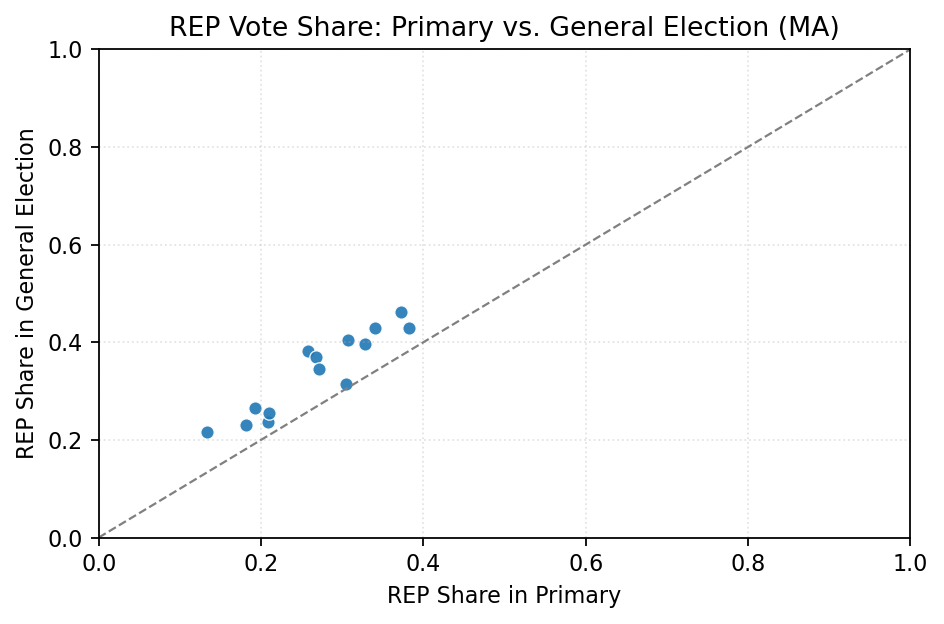

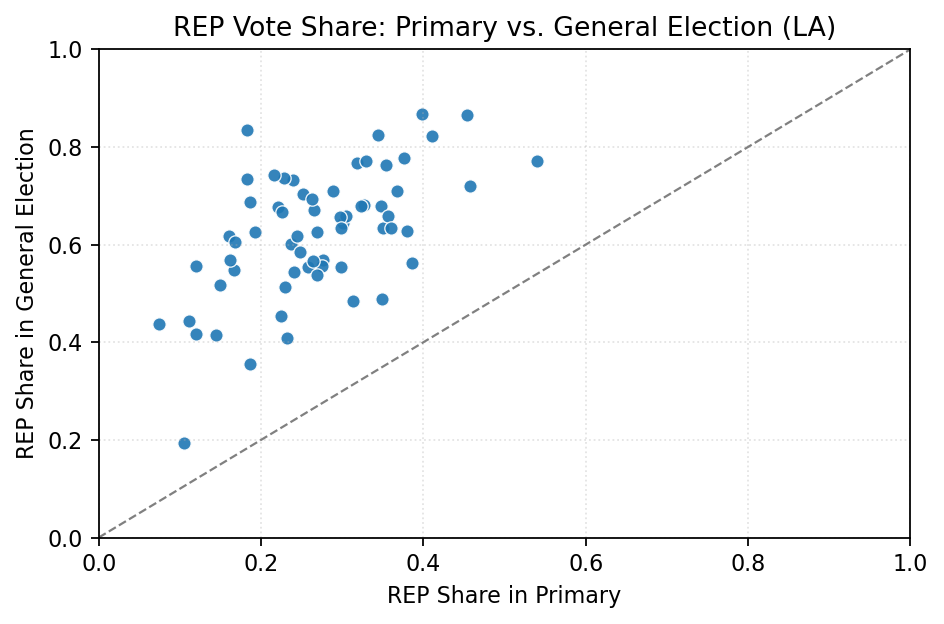

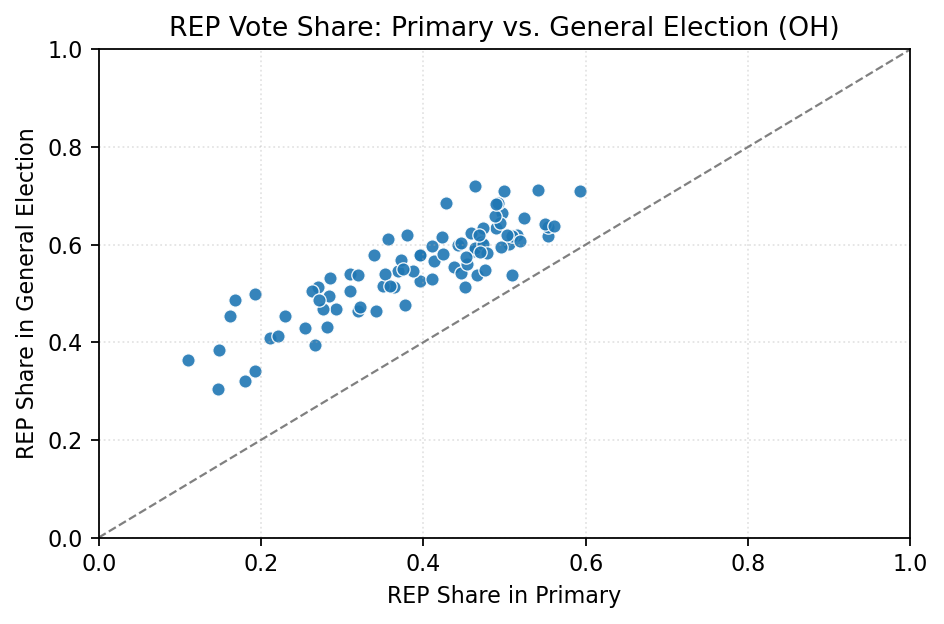

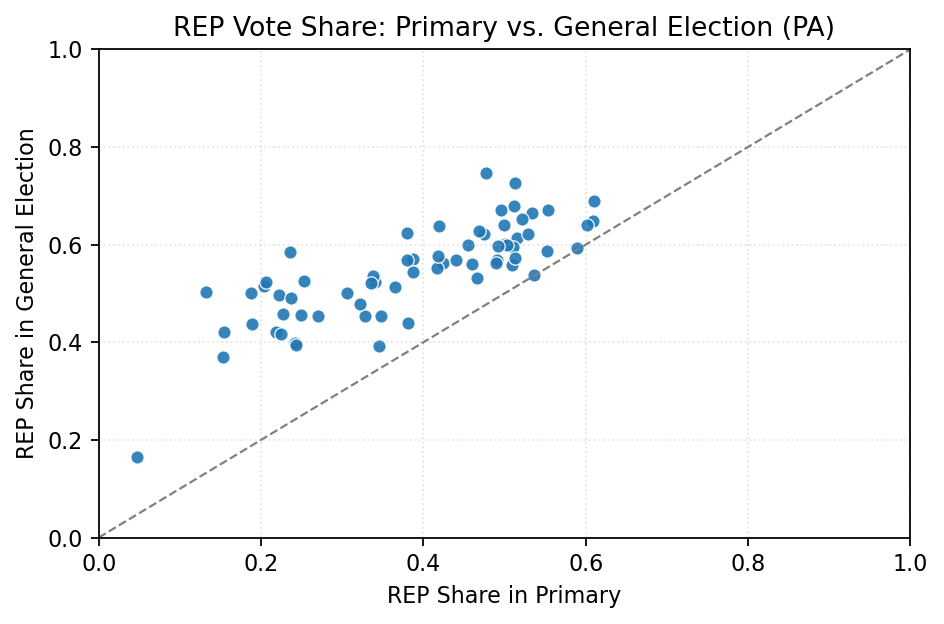

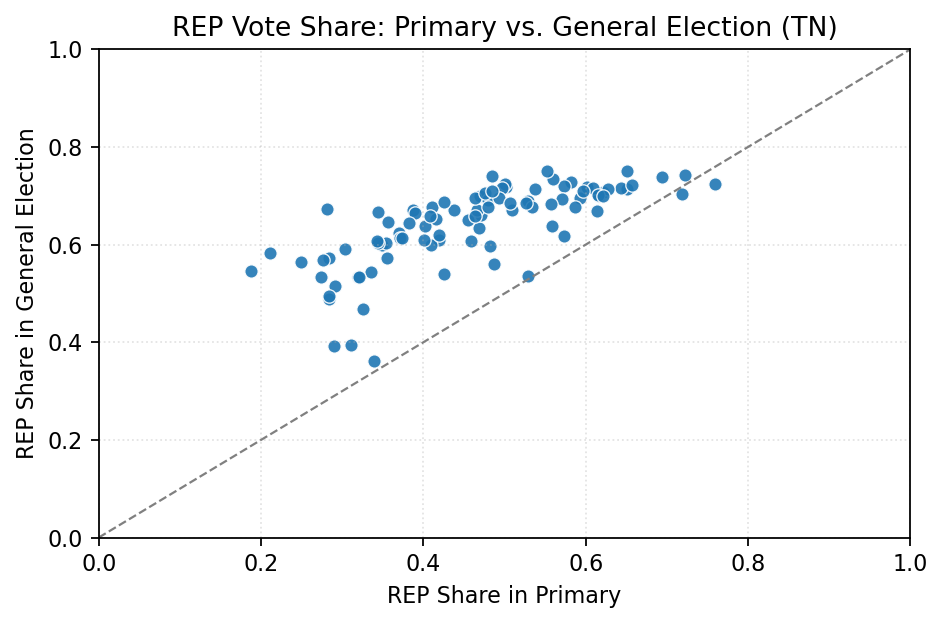

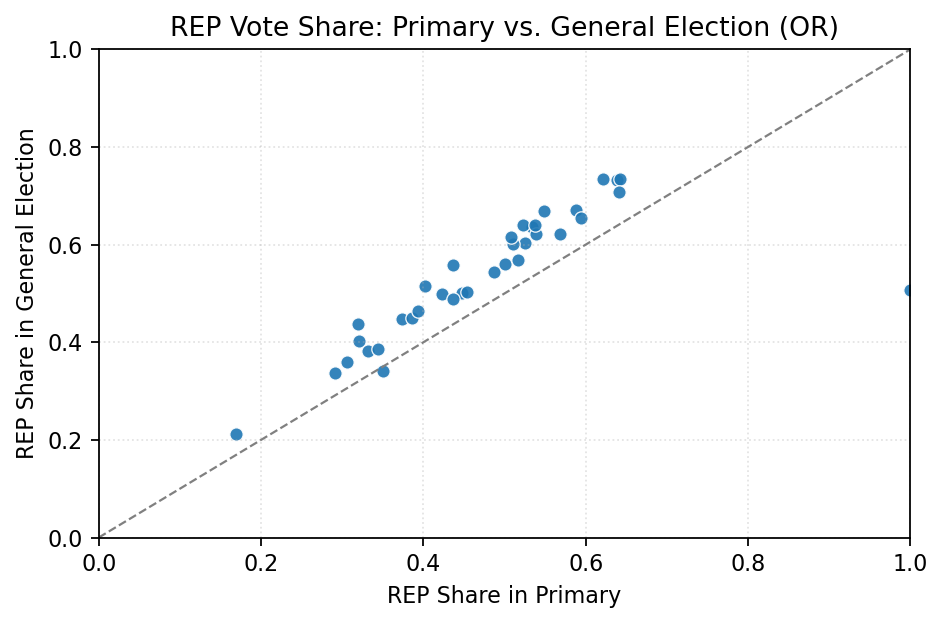

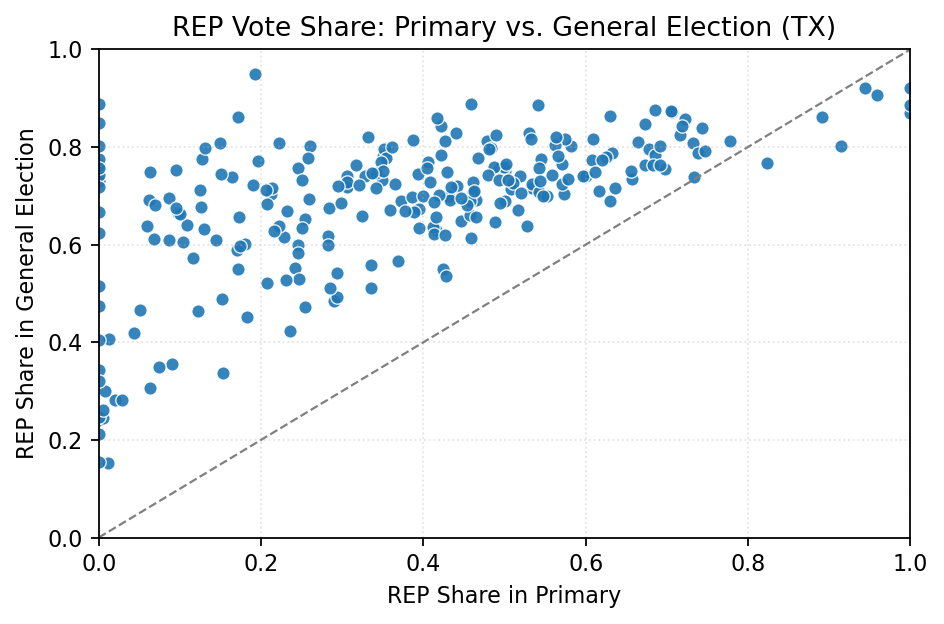

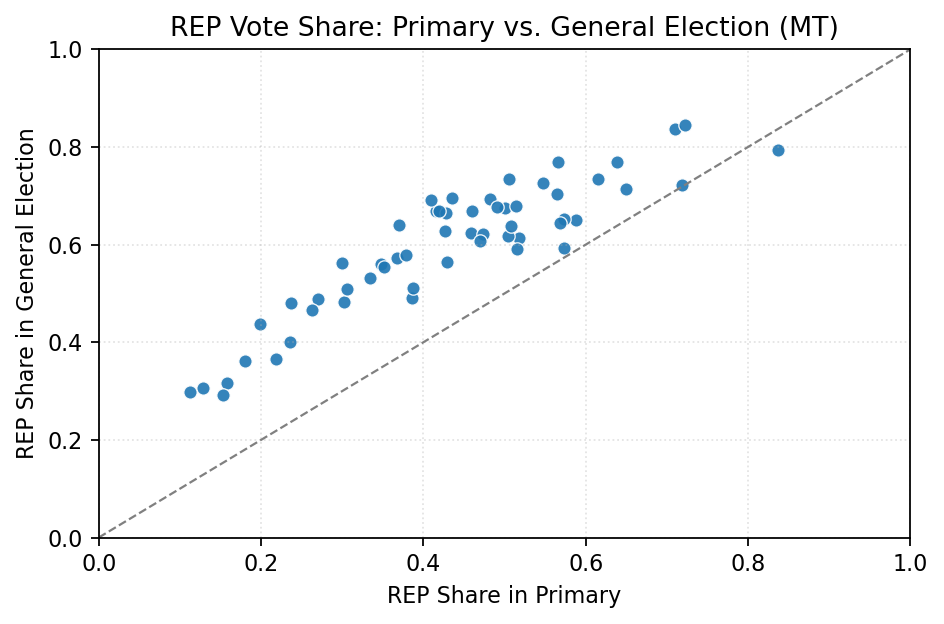

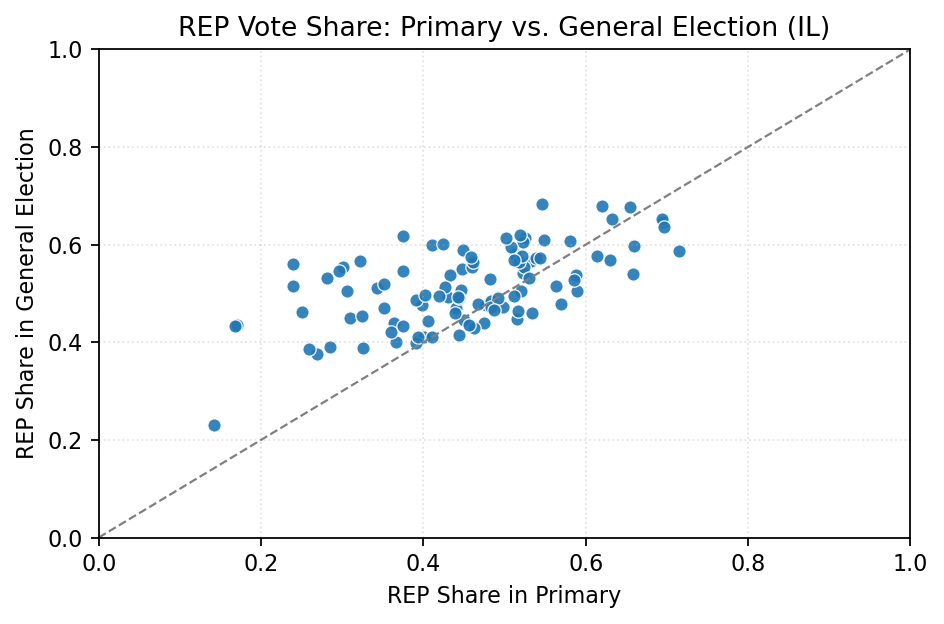

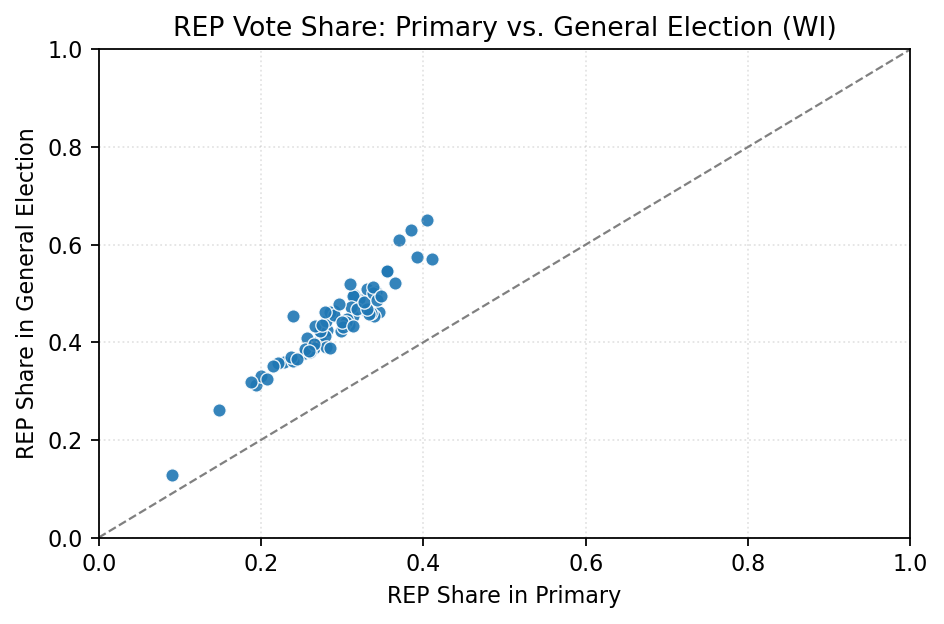

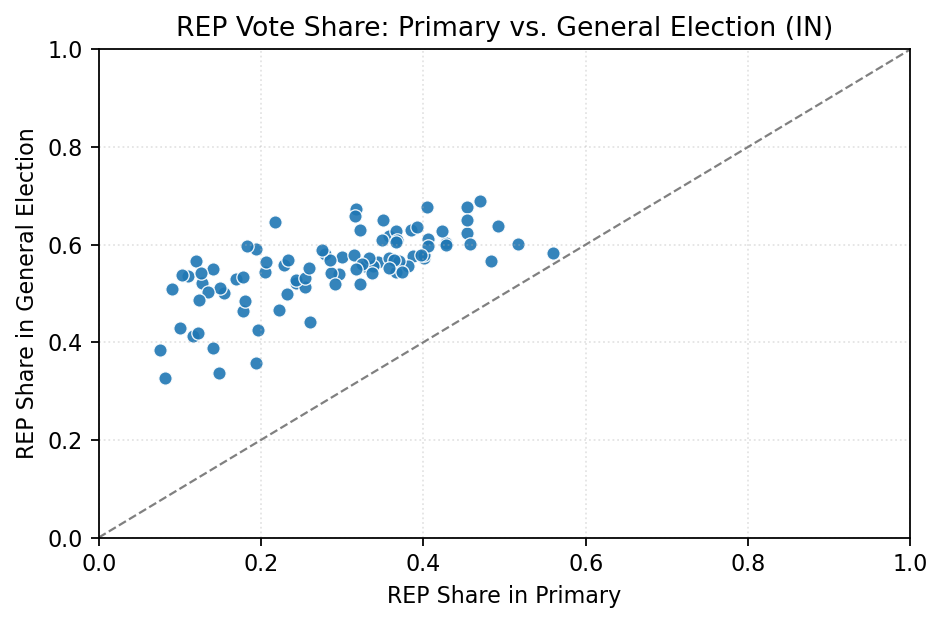

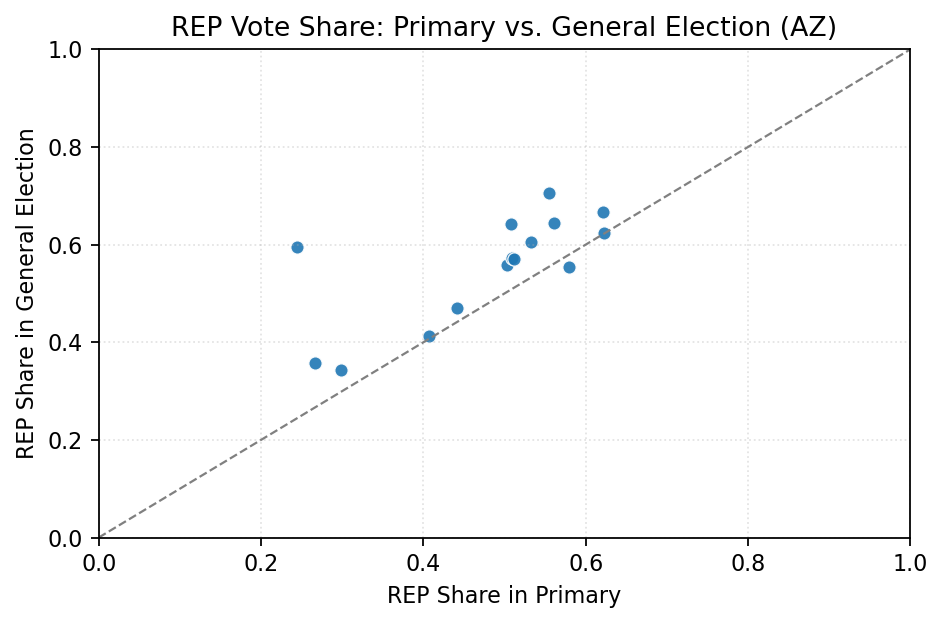

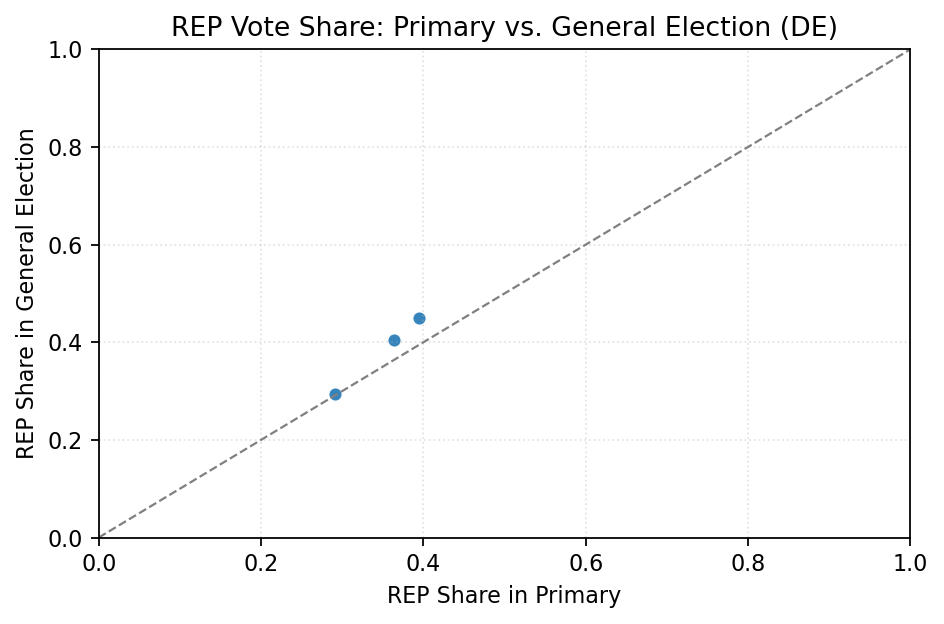

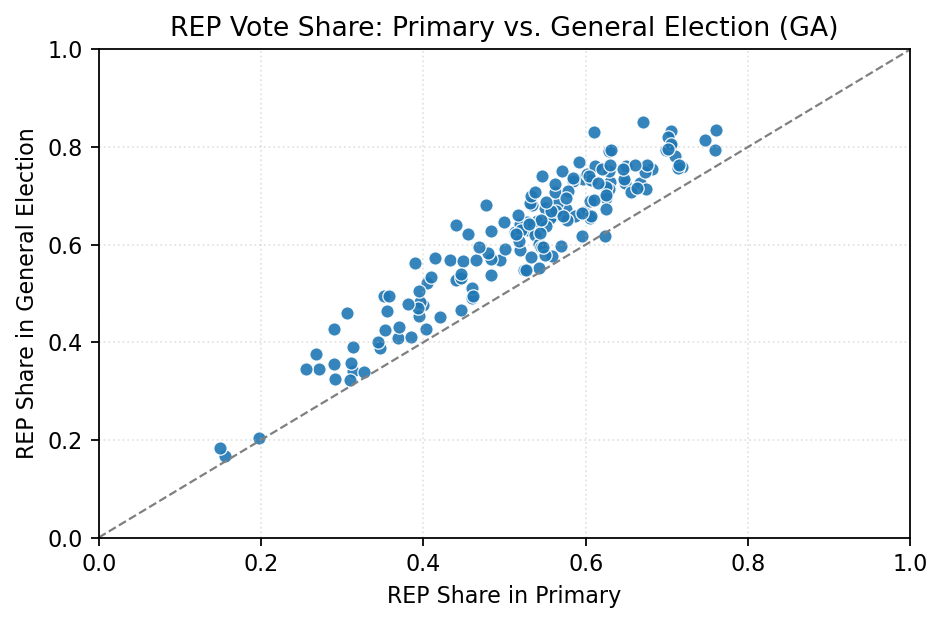

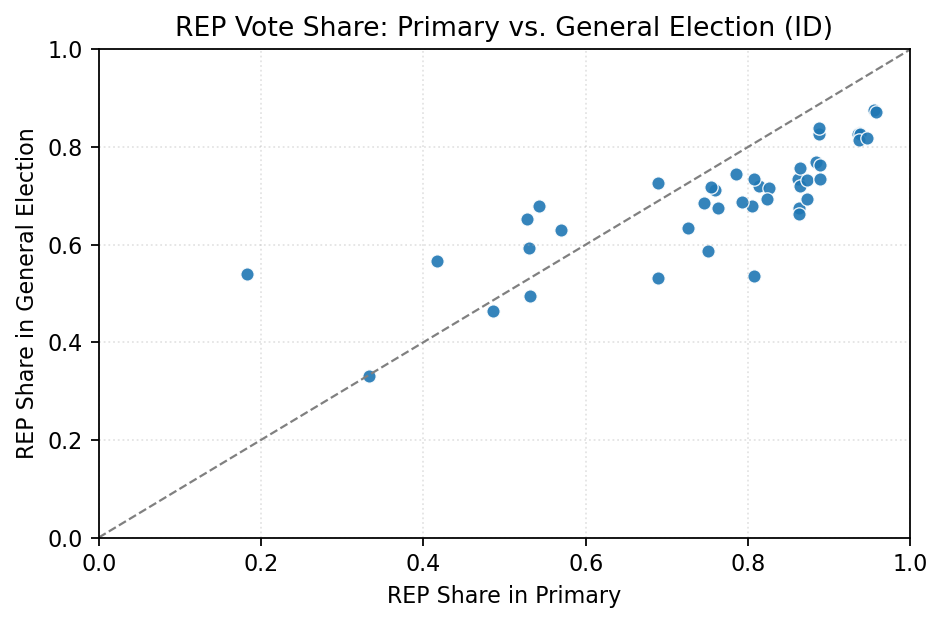

In [27]:
# Plot the REP vote share in primary vs general for each individual state
states = set(dt1_subset["state"].values)

for state in states:
    fig, ax = plt.subplots(figsize=(6, 4), dpi=160)

    # Filter data for the current state 
    state_df = dt1_subset[dt1_subset["state"] == state]
    
    # Scatter plot
    sc = ax.scatter(
        state_df["rep_primary_share"], state_df["rep_general_share"],
        s = 36,
        alpha = 0.9,
        edgecolors = "white",
        linewidths = 0.6
    )

    # 45° reference line (y = x)
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)

    # cosmetics
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("REP Share in Primary")
    ax.set_ylabel("REP Share in General Election")
    ax.set_title(f"REP Vote Share: Primary vs. General Election ({state})")
    ax.grid(True, linestyle=":", alpha=0.35)

    plt.tight_layout()
    plt.show()

### 2.2. 2016 Presidential Election

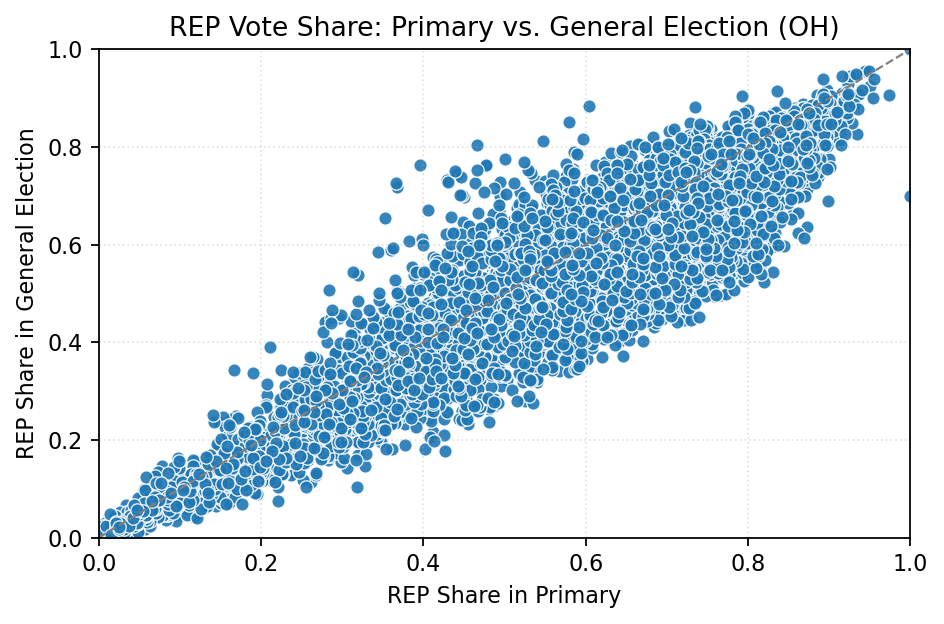

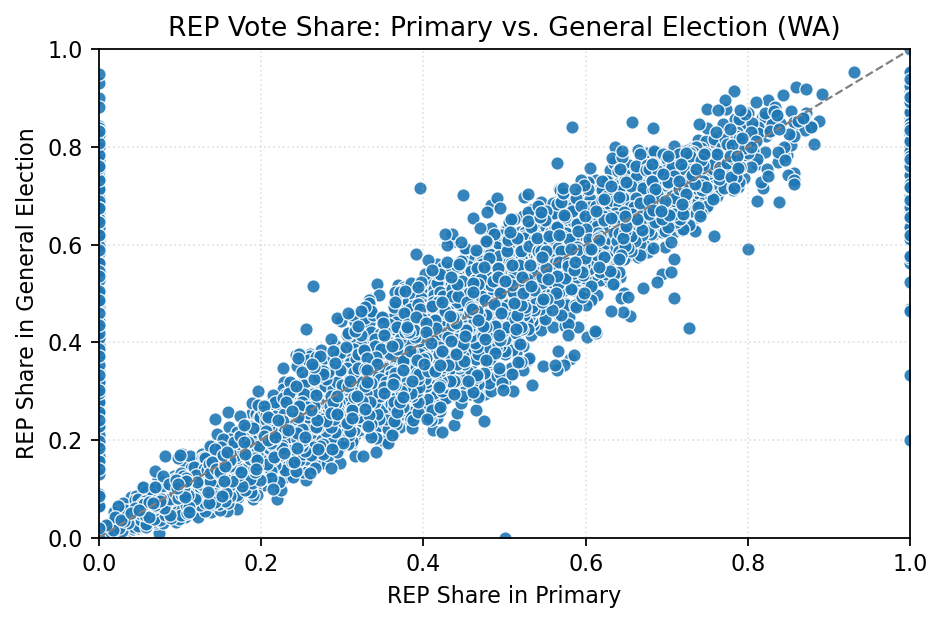

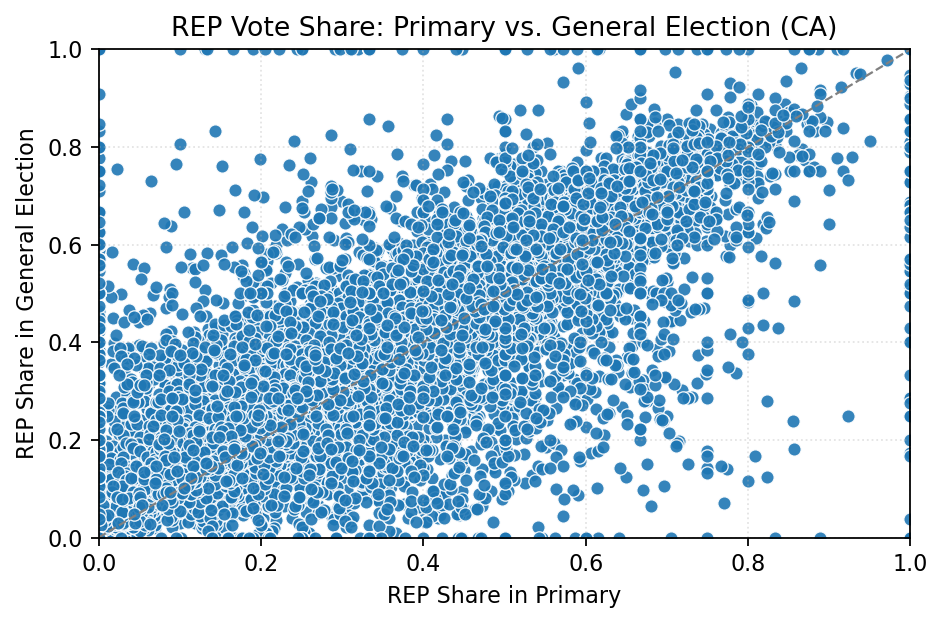

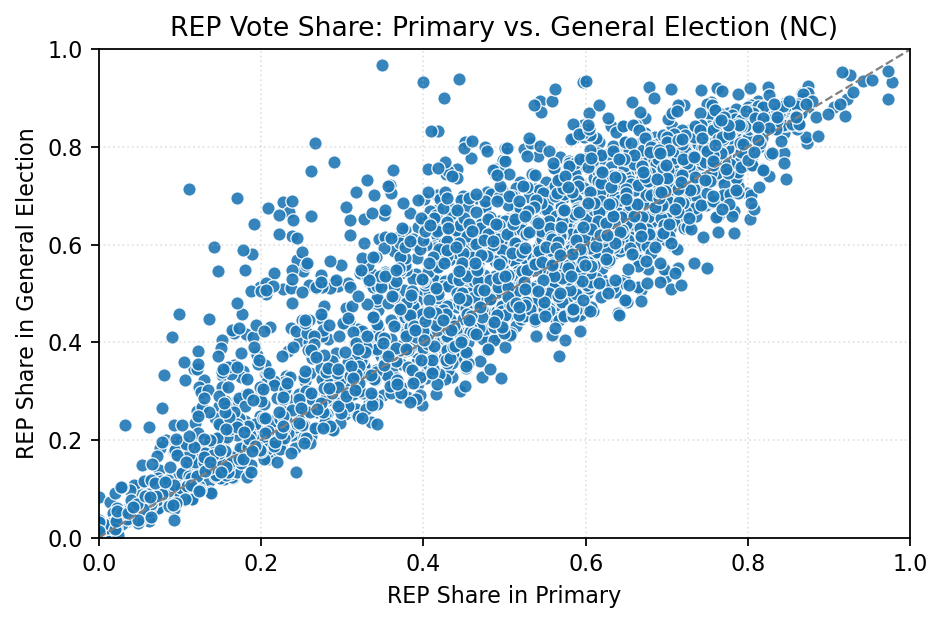

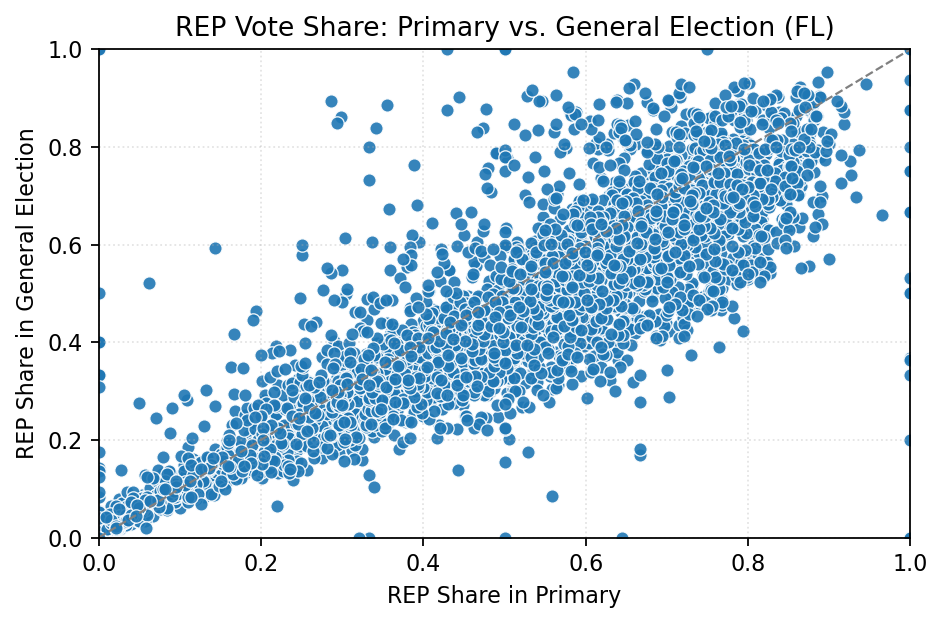

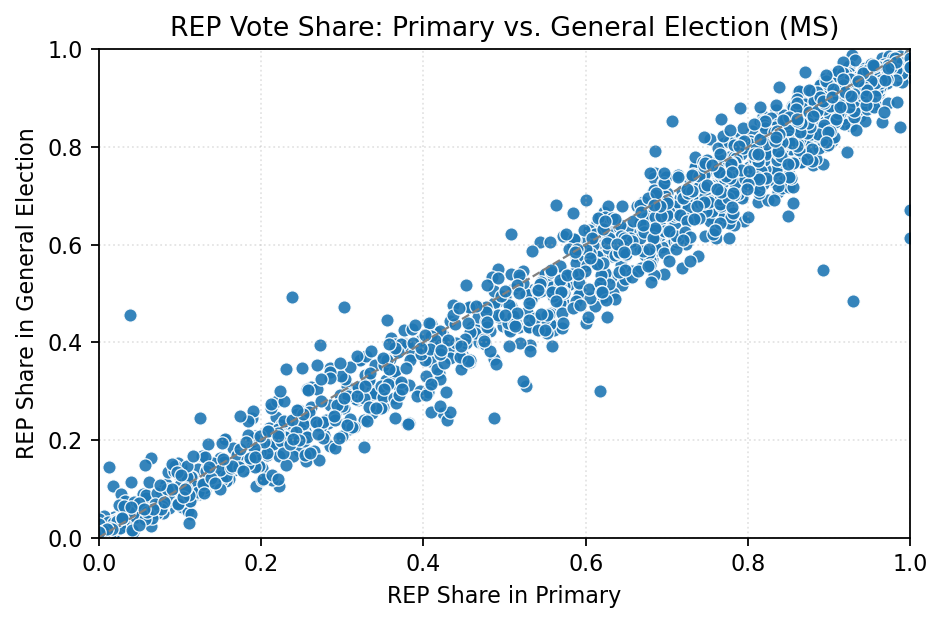

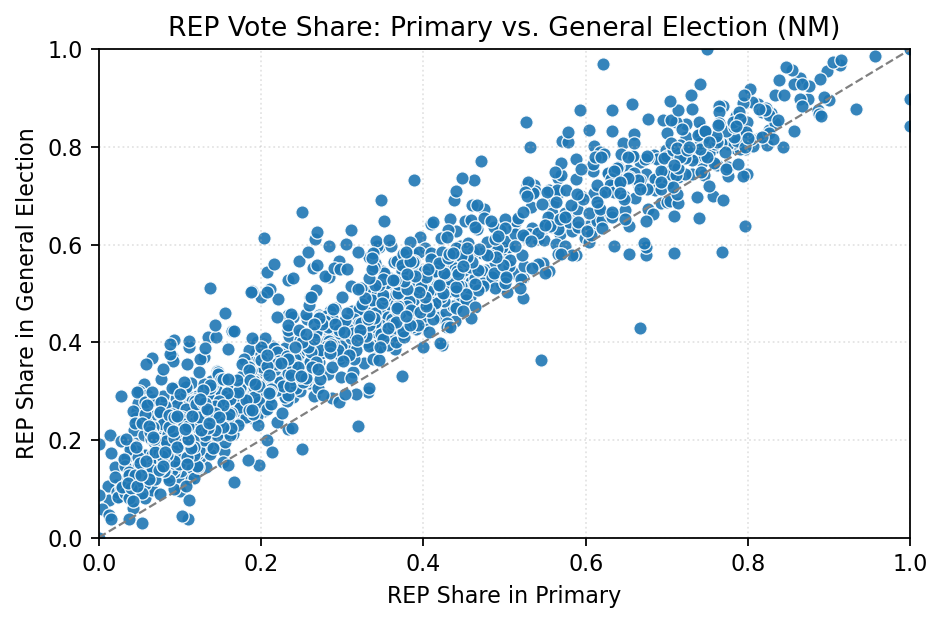

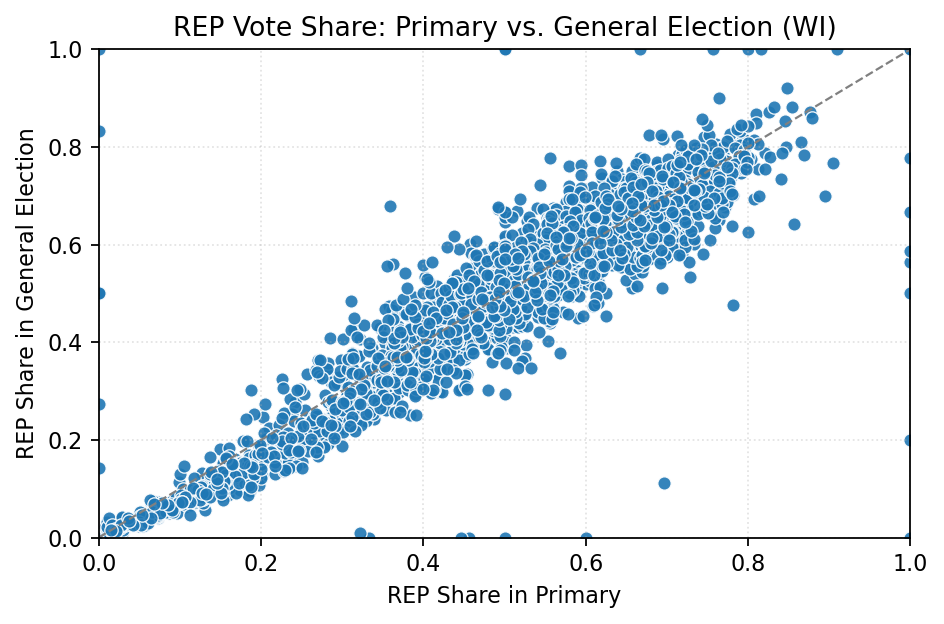

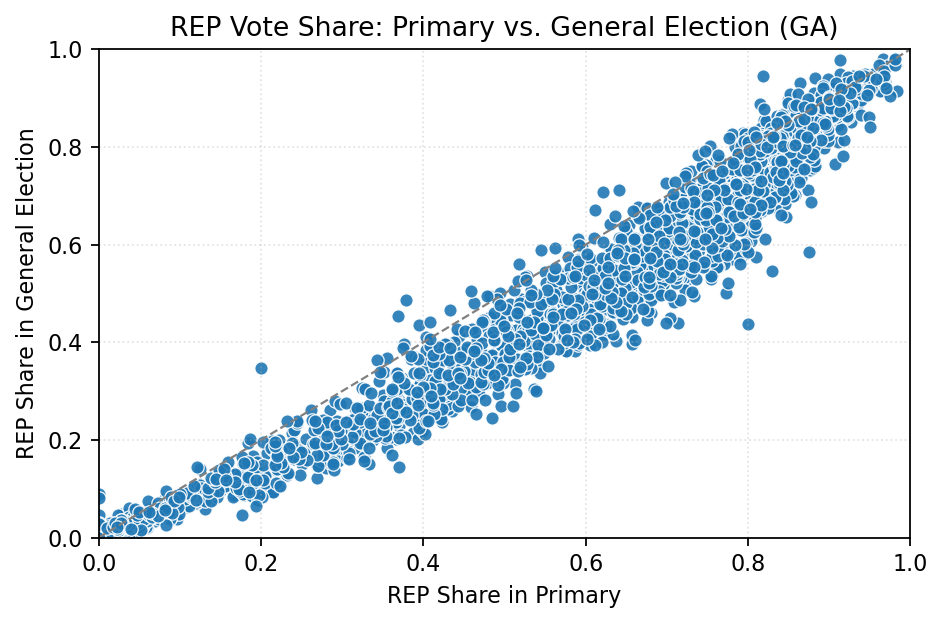

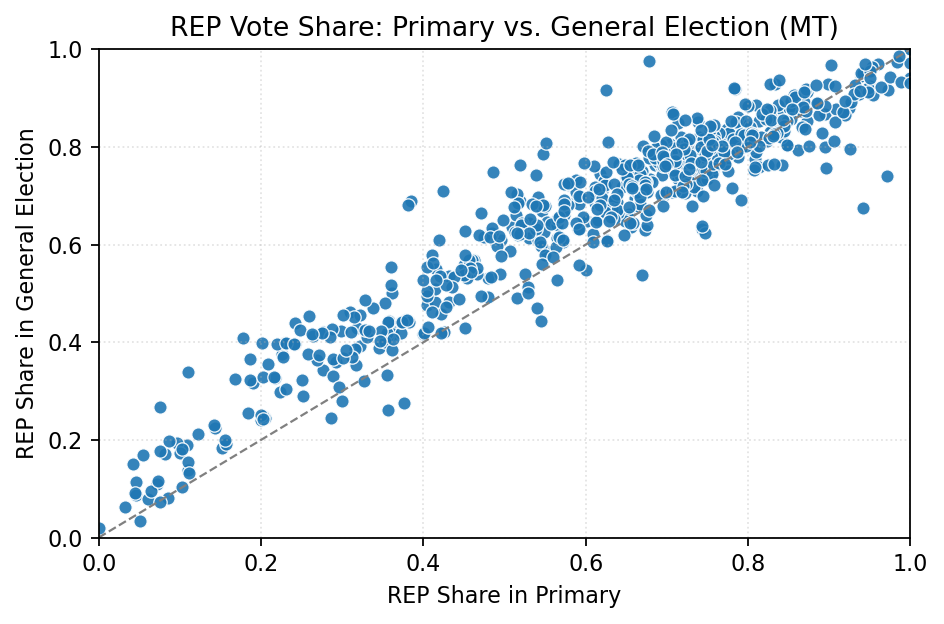

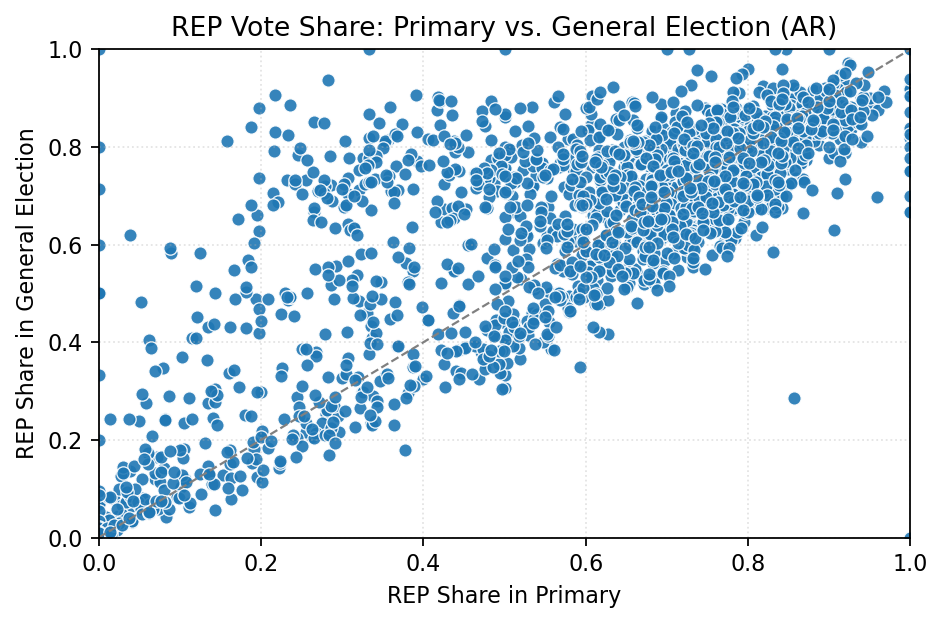

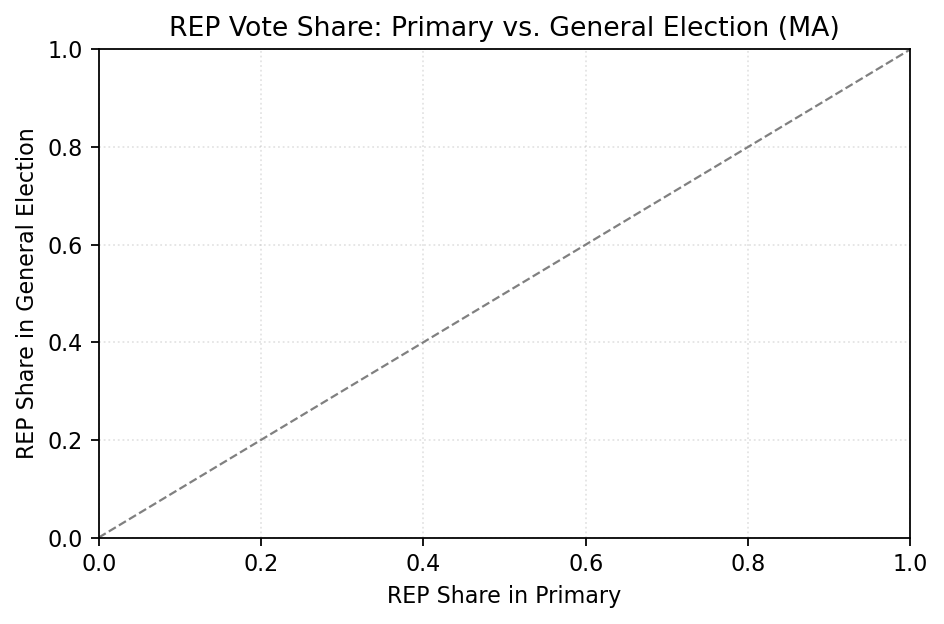

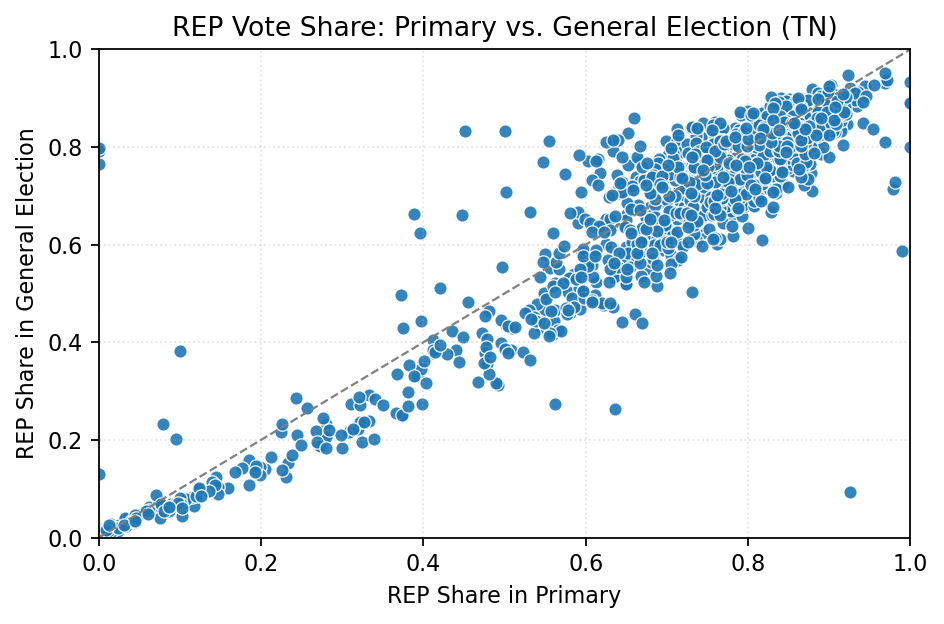

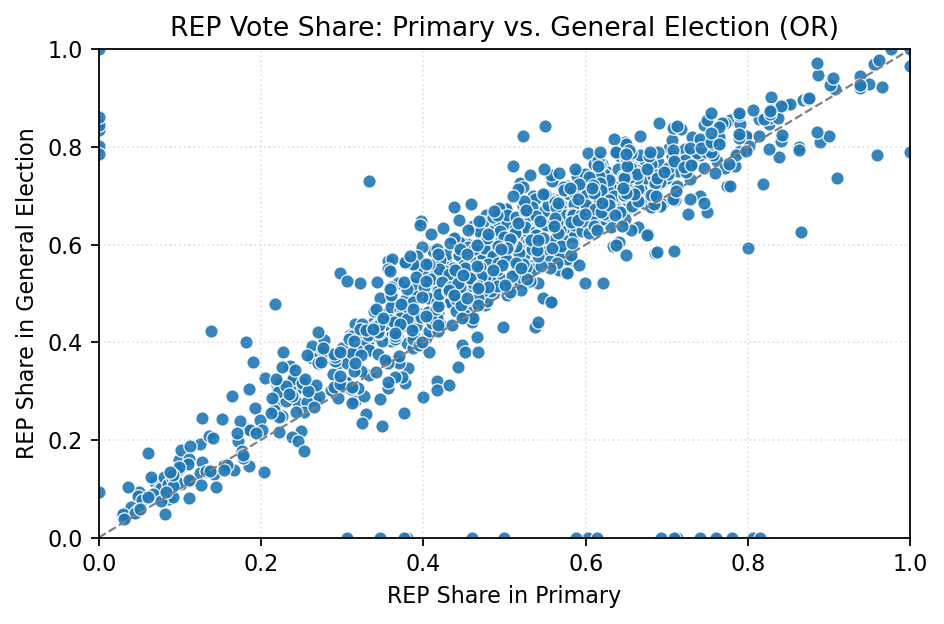

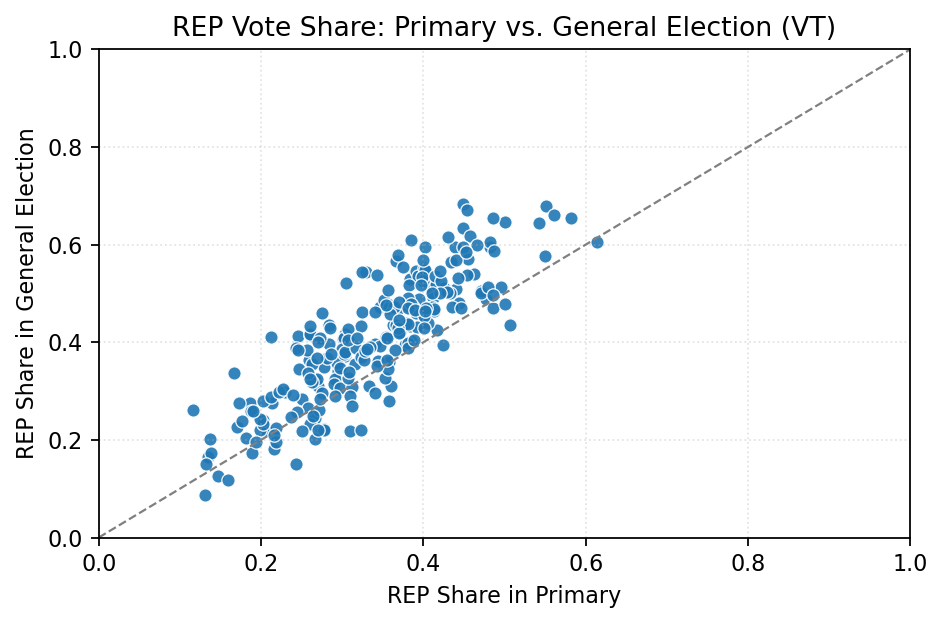

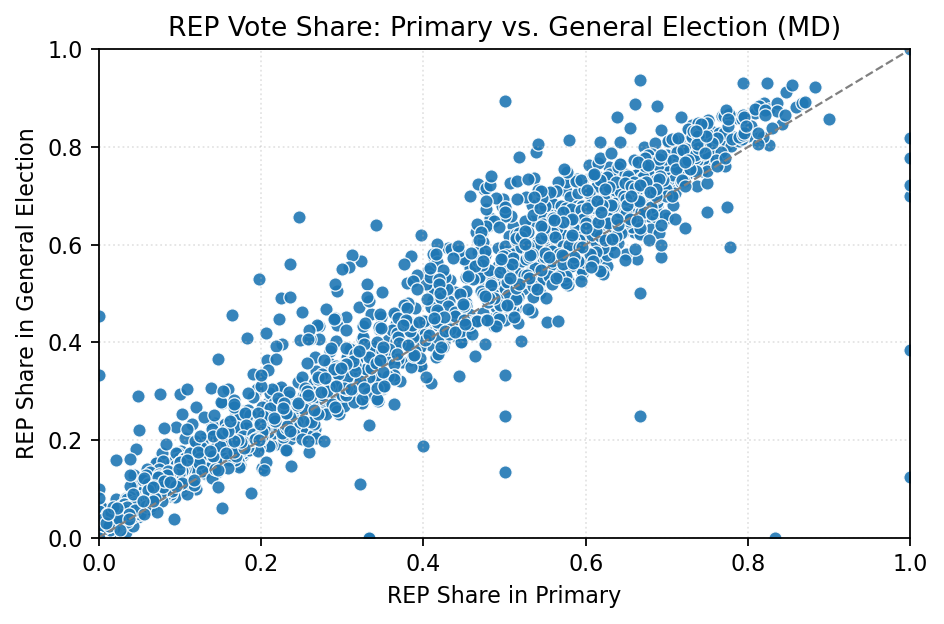

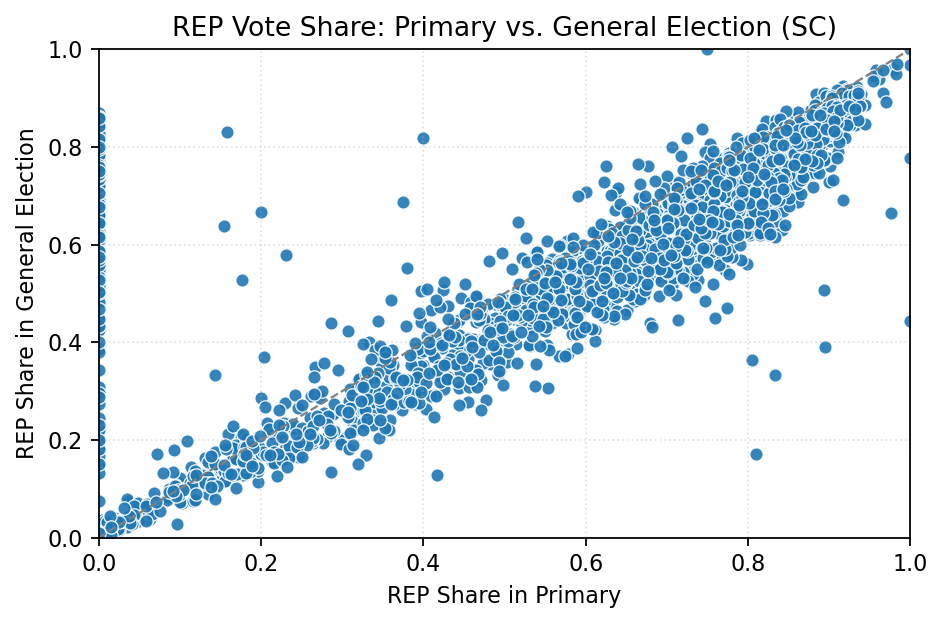

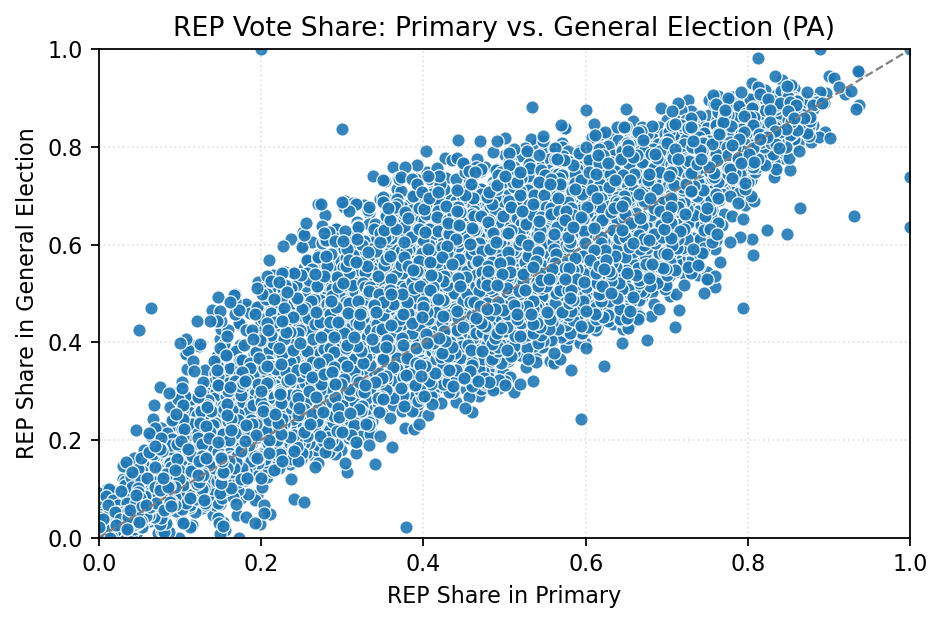

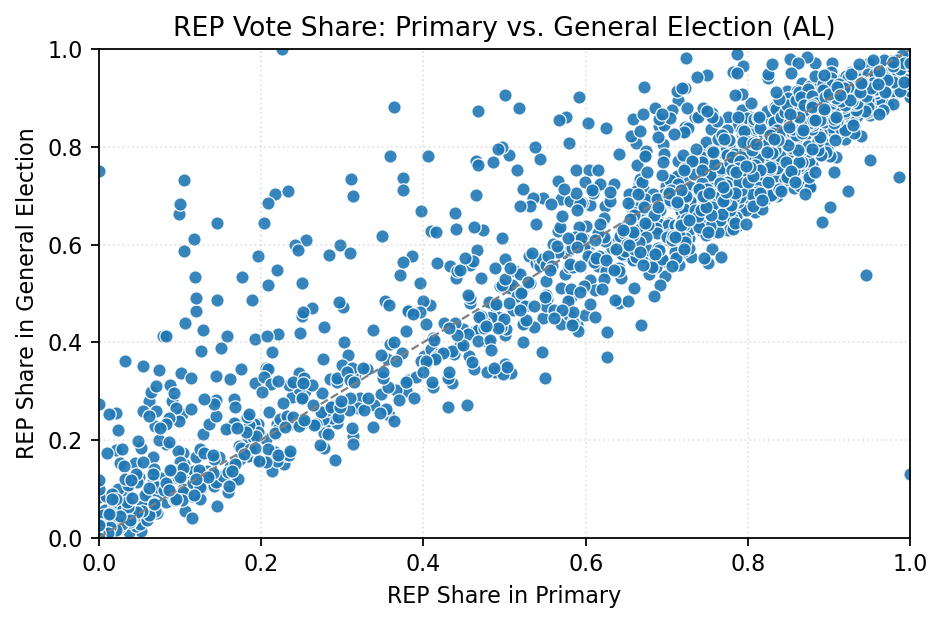

In [28]:
# Plot the REP vote share in primary vs general for each individual state
states = set(dt2_subset["state"].values)

for state in states:
    fig, ax = plt.subplots(figsize=(6, 4), dpi=160)

    # Filter data for the current state 
    state_df = dt2_subset[dt2_subset["state"] == state]
    
    # Scatter plot
    sc = ax.scatter(
        state_df["rep_primary_share"], state_df["rep_general_share"],
        s = 36,
        alpha = 0.9,
        edgecolors = "white",
        linewidths = 0.6
    )

    # 45° reference line (y = x)
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)

    # cosmetics
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("REP Share in Primary")
    ax.set_ylabel("REP Share in General Election")
    ax.set_title(f"REP Vote Share: Primary vs. General Election ({state})")
    ax.grid(True, linestyle=":", alpha=0.35)

    plt.tight_layout()
    plt.show()

### 2.3. 2020 Presidential Election

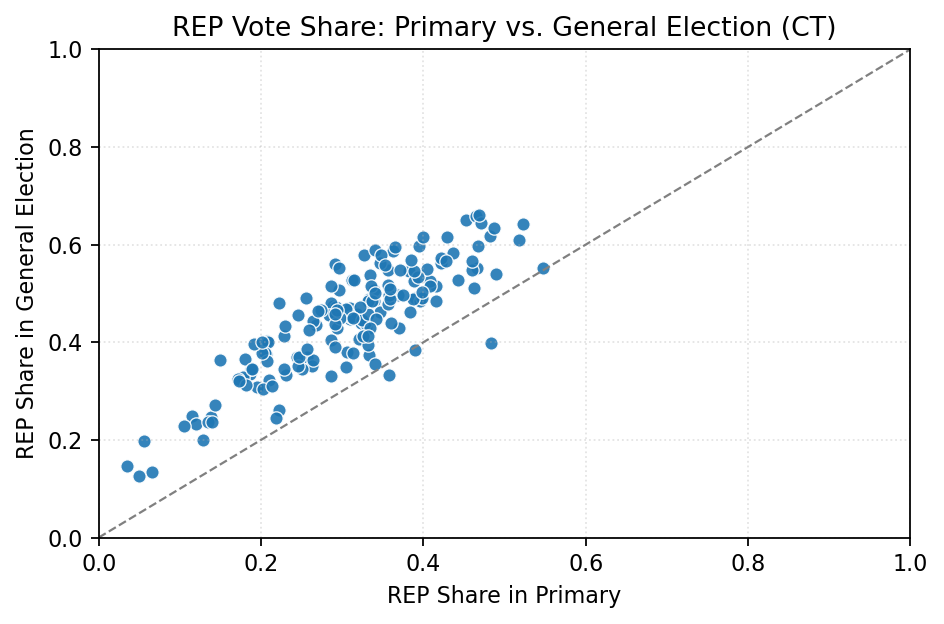

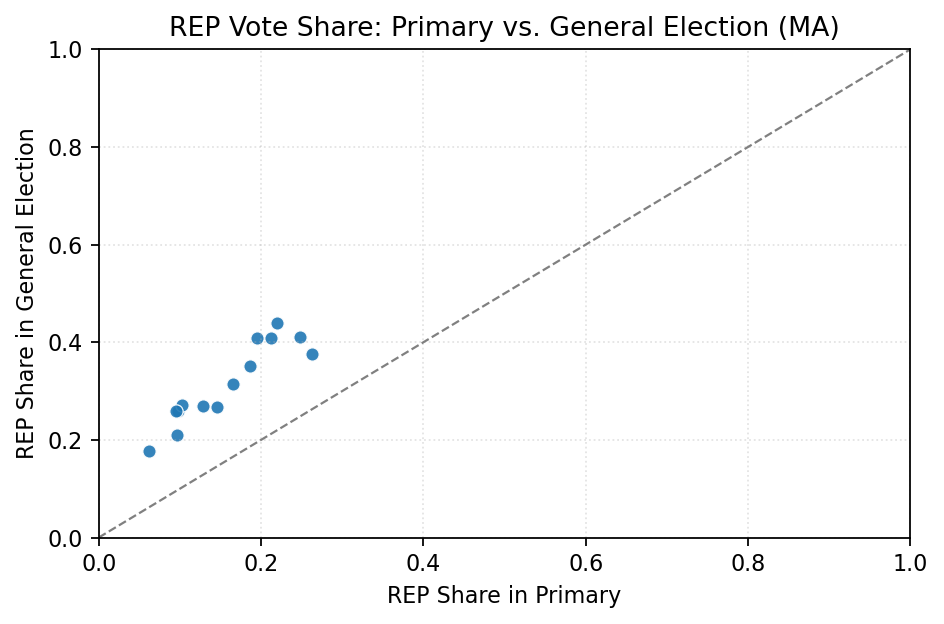

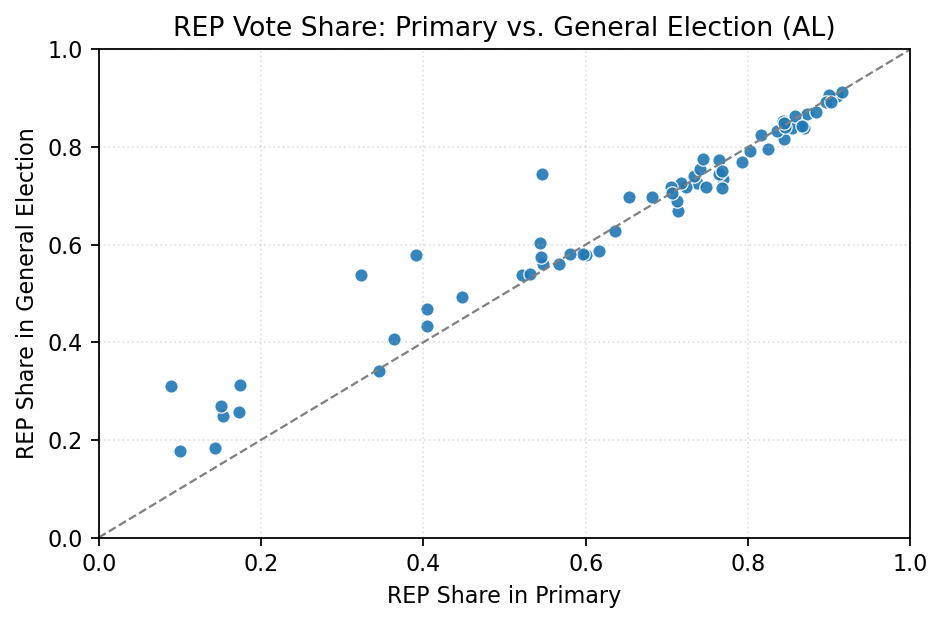

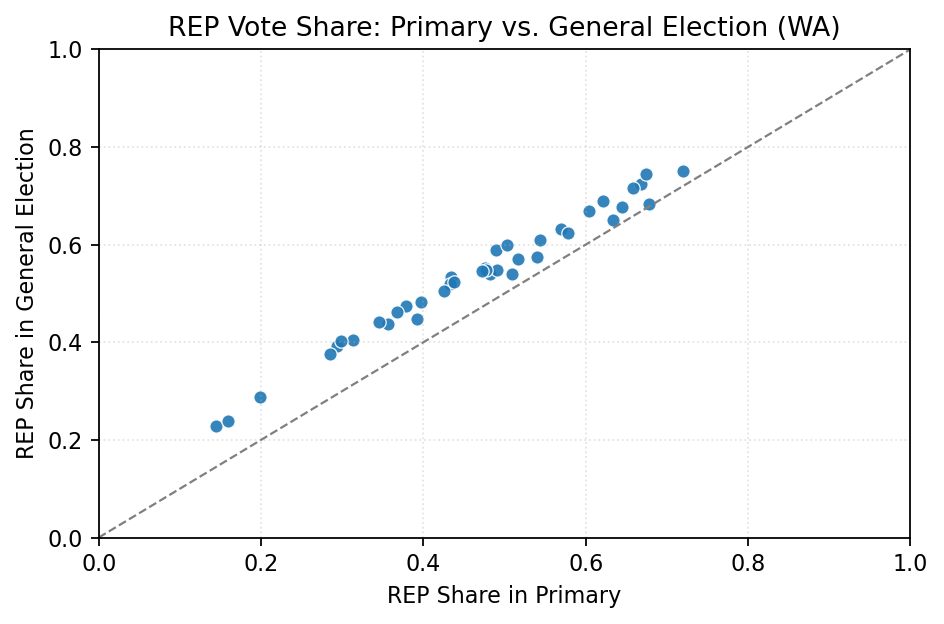

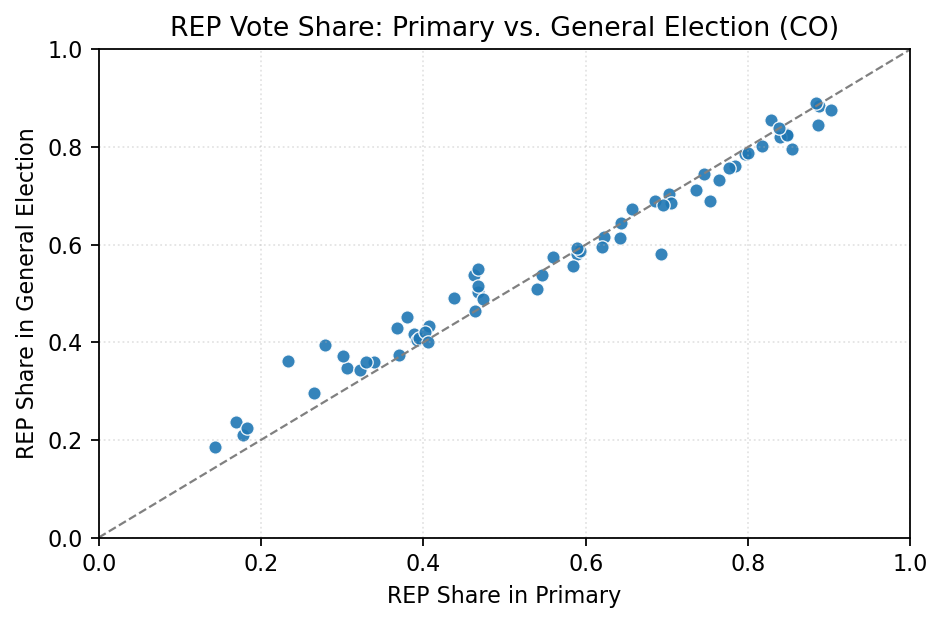

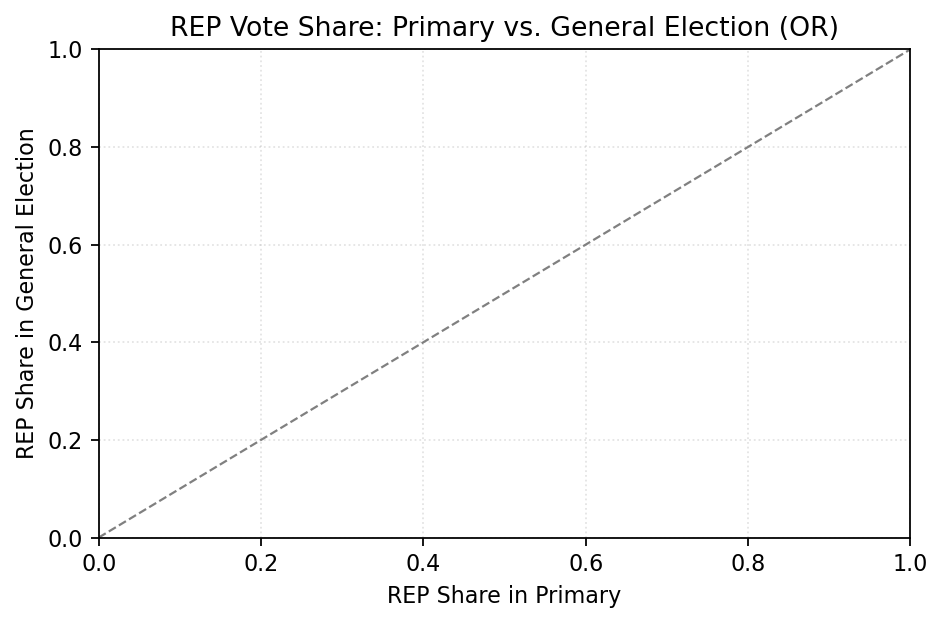

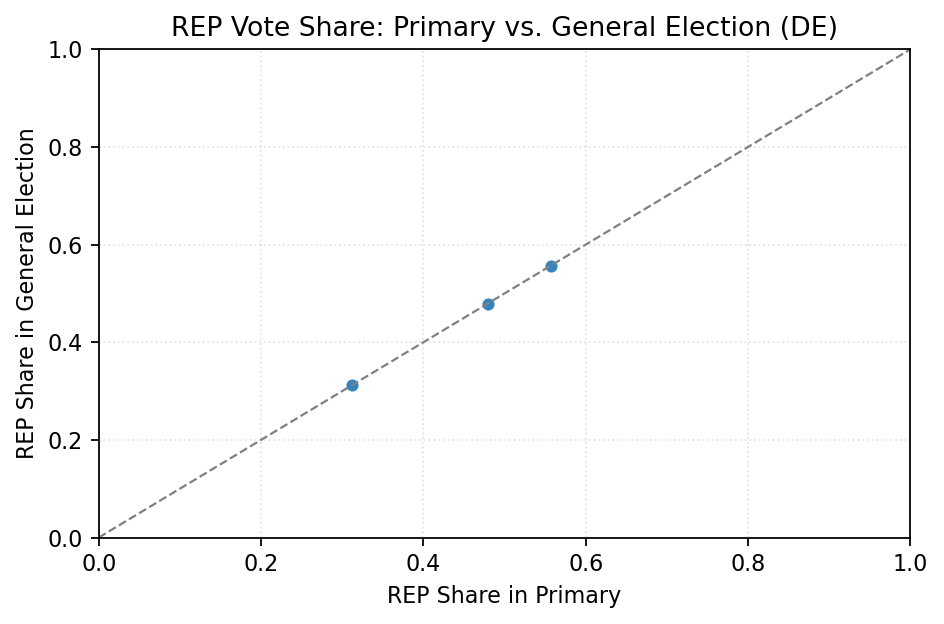

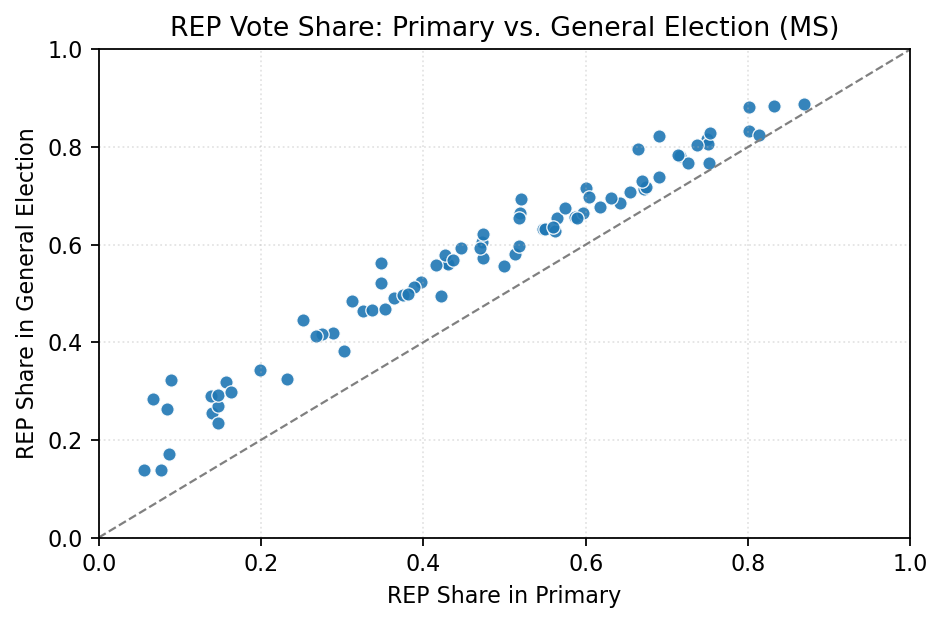

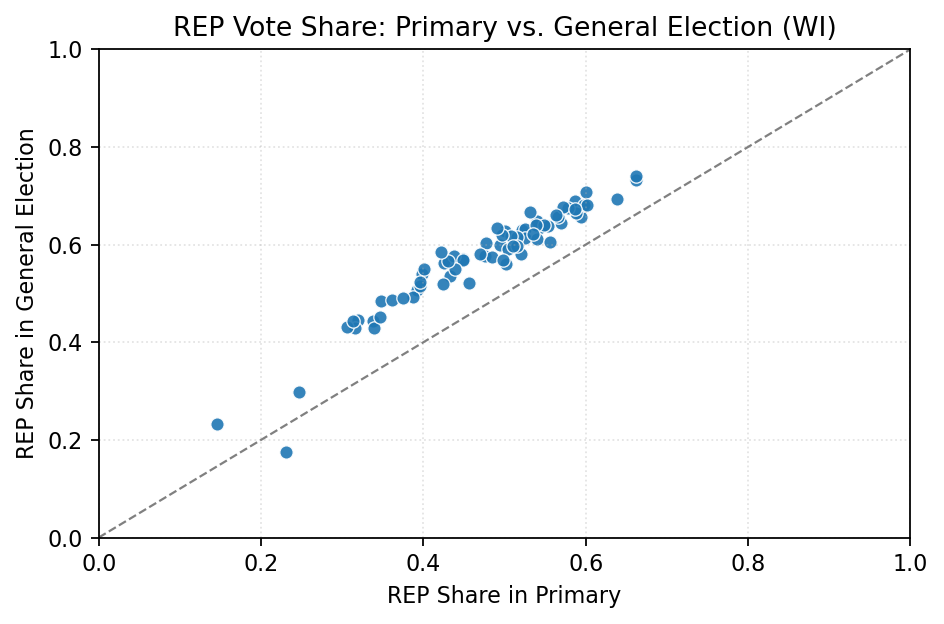

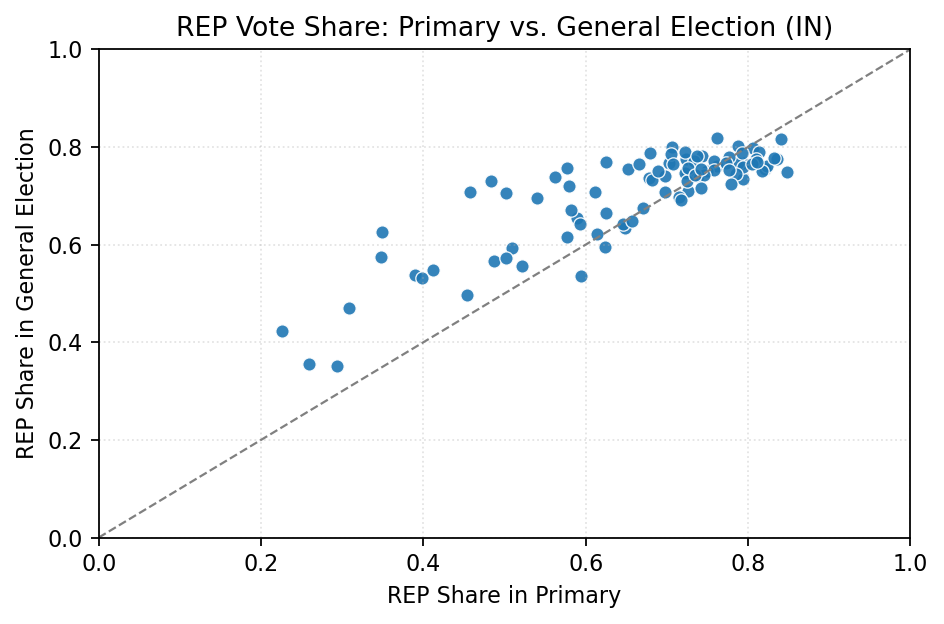

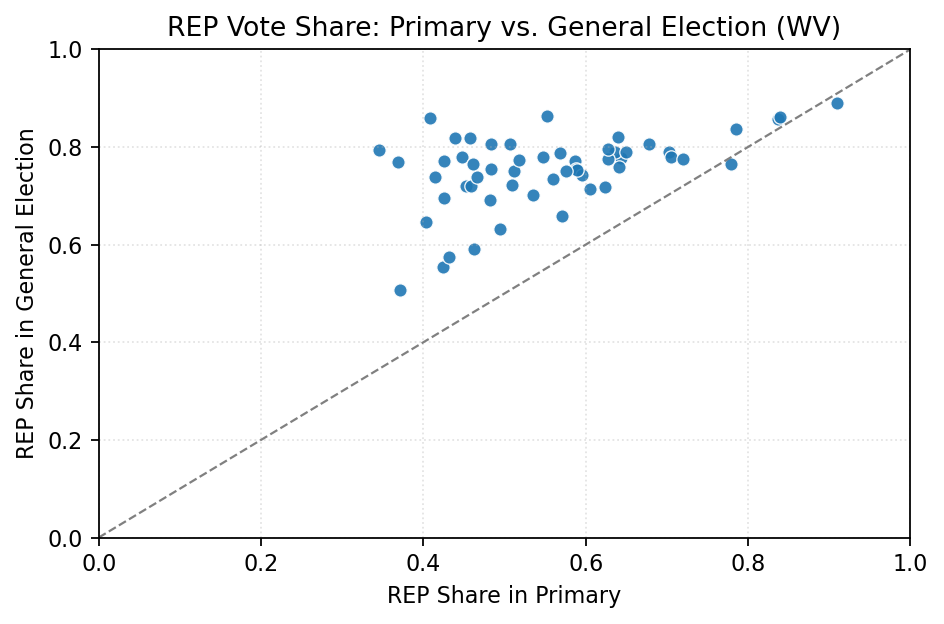

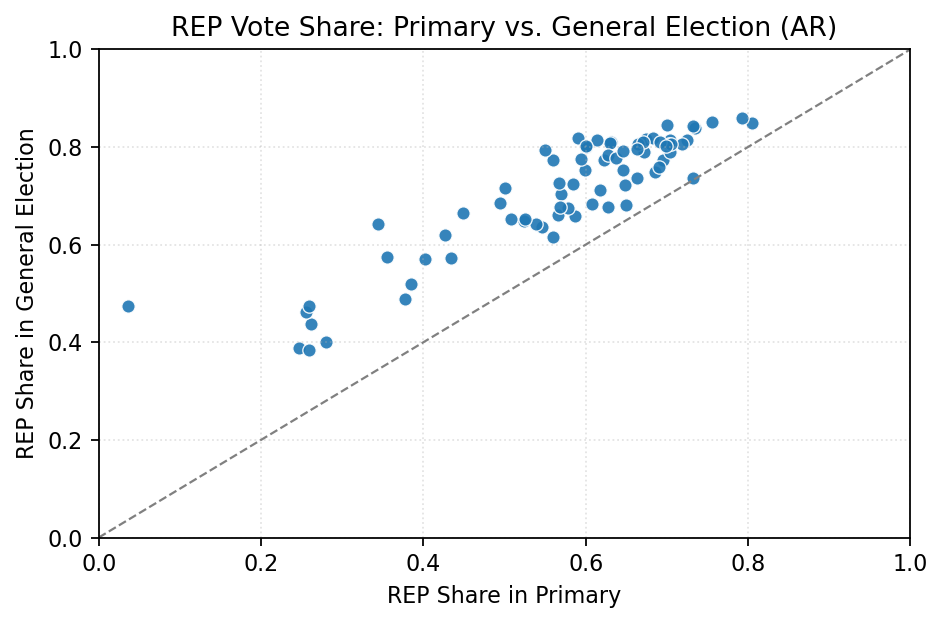

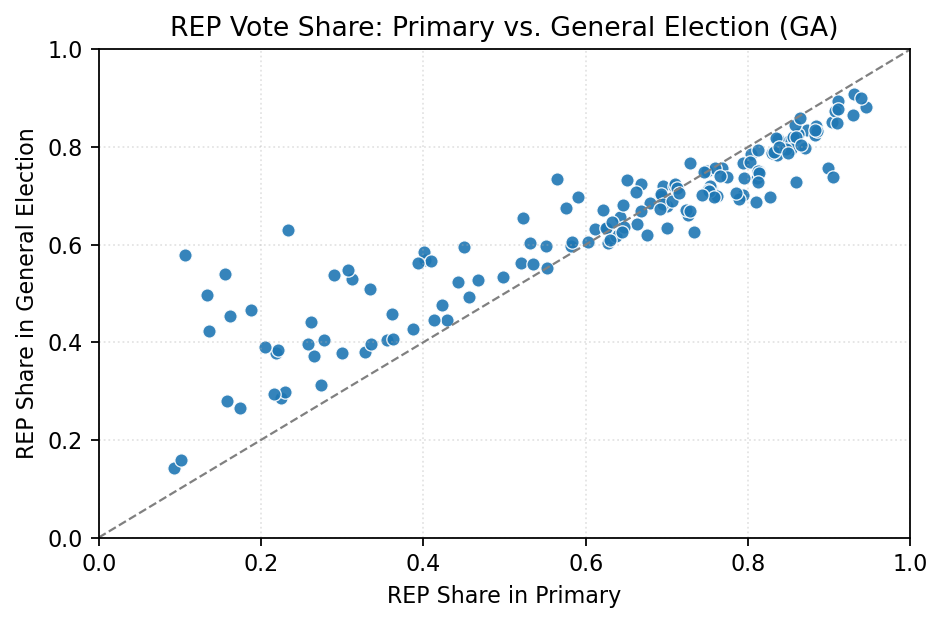

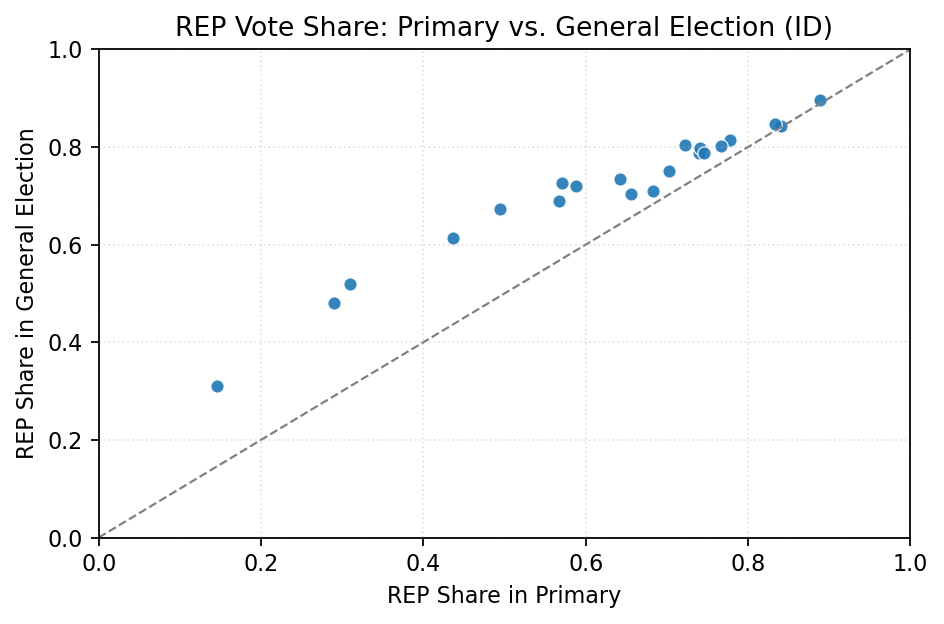

In [9]:
# Plot the REP vote share in primary vs general for each individual state
states = set(dt3_subset["state"].values)

for state in states:
    fig, ax = plt.subplots(figsize=(6, 4), dpi=160)

    # Filter data for the current state 
    state_df = dt3_subset[dt3_subset["state"] == state]
    
    # Scatter plot
    sc = ax.scatter(
        state_df["rep_primary_share"], state_df["rep_general_share"],
        s = 36,
        alpha = 0.9,
        edgecolors = "white",
        linewidths = 0.6
    )

    # 45° reference line (y = x)
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)

    # cosmetics
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("REP Share in Primary")
    ax.set_ylabel("REP Share in General Election")
    ax.set_title(f"REP Vote Share: Primary vs. General Election ({state})")
    ax.grid(True, linestyle=":", alpha=0.35)

    plt.tight_layout()
    plt.show()

## 3. Multistate REP Overperformance vs REP Primary Share

Here we switch from **within-state** to **across-state** summaries by collapsing each state to *one point*.

For each state we compute:  
- **x** = average REP primary share (state-level)  
- **y** = “REP overperformance” = average REP general share − average REP primary share  

So `y > 0` means REP gained share from primary to general (on average), and `y < 0` means REP lost share. Bubble size scales with total general-election votes (so large states visually matter more), and color encodes whether the **weighted** general-election REP share is above or below 50%. The fitted line is a **vote-weighted** regression, and the annotation box reports the line equation and an $R^2$ for how much of the state-to-state variation is explained by x.


### 3.1. 2008 Presidential Election

/var/folders/10/yh5g9ksn5fb_2pzdwtzd2tlh0000gn/T/ipykernel_22721/4158180759.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


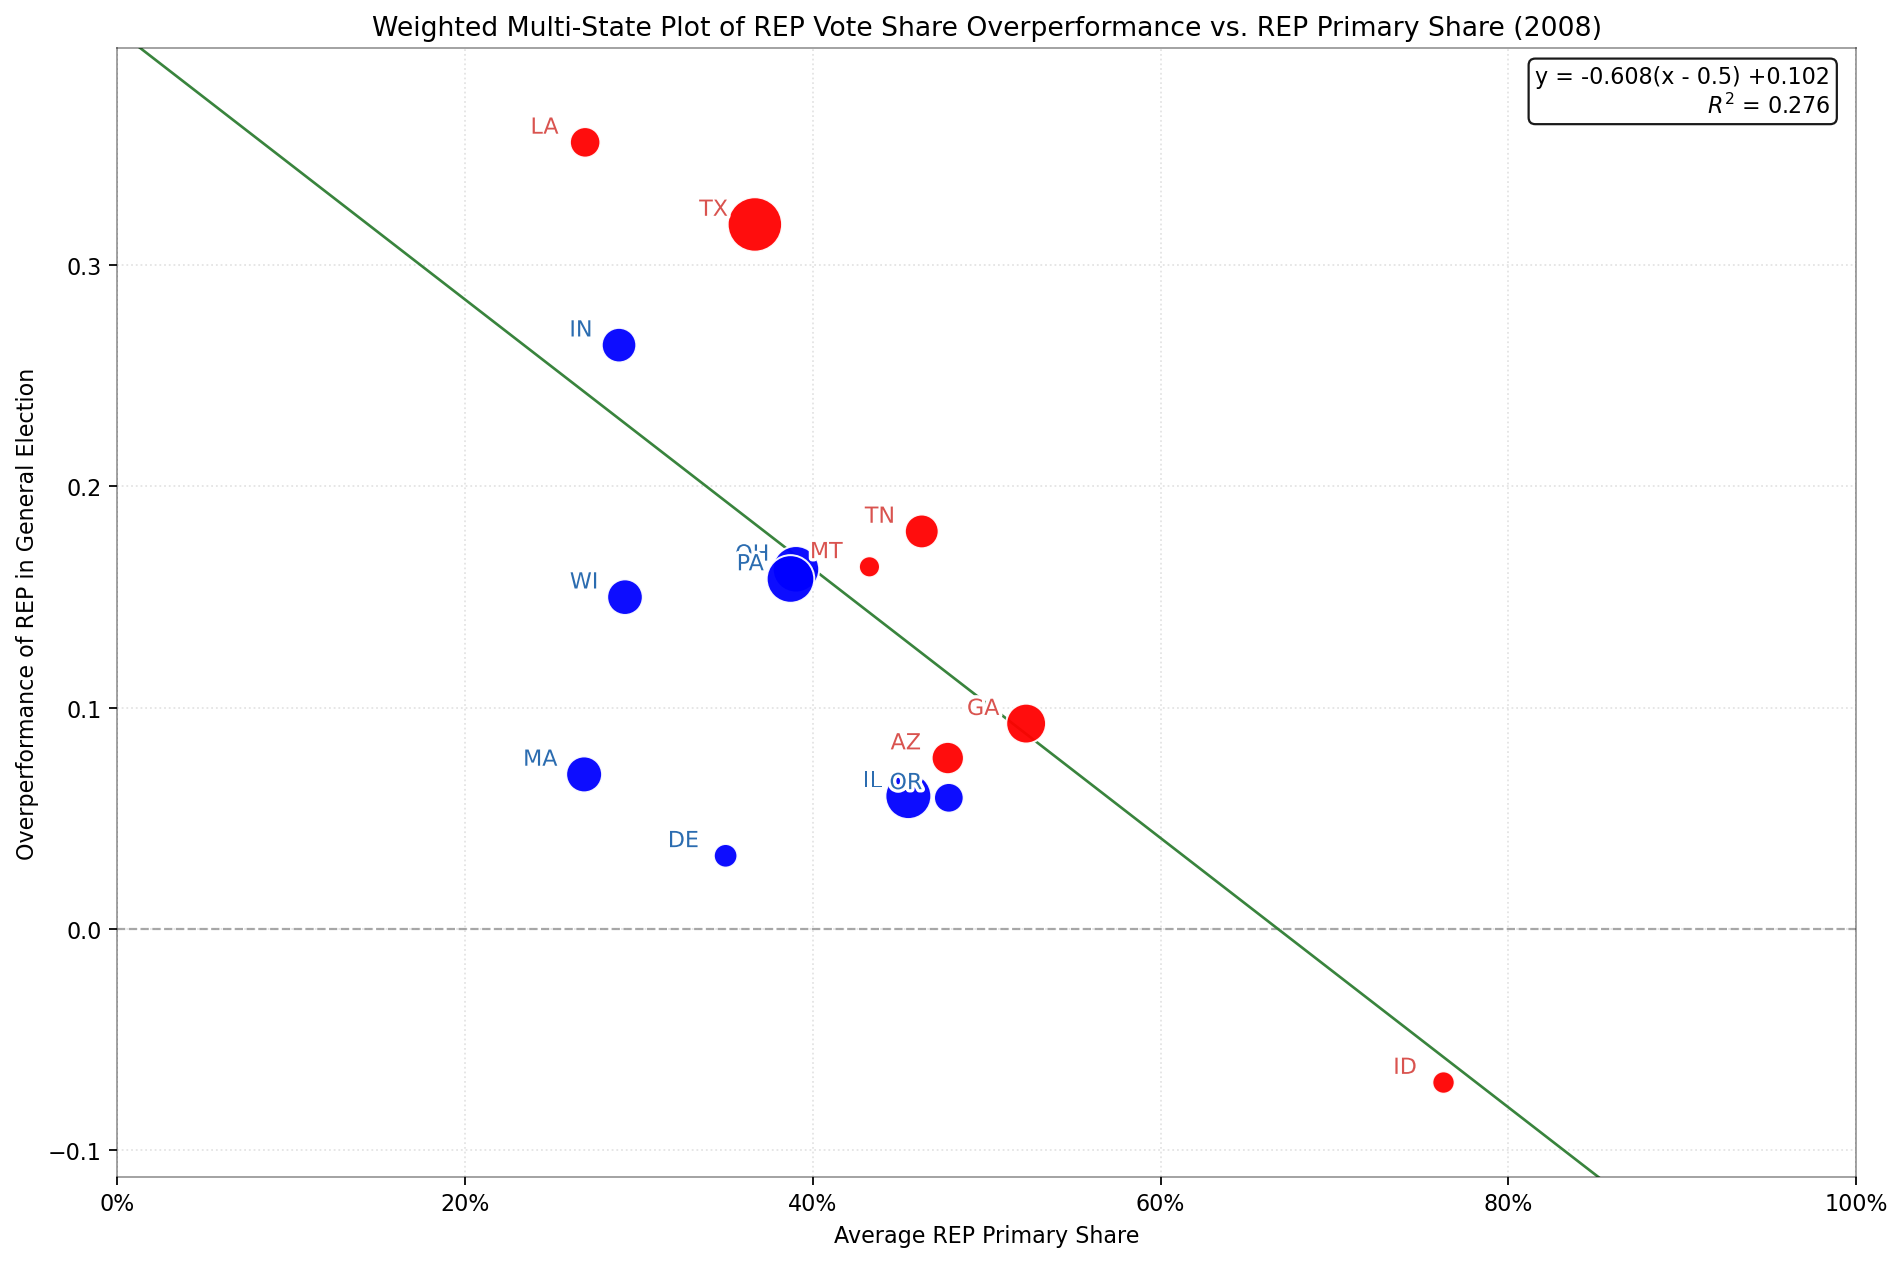

In [29]:
# Multistate REP Overperformance vs REP Primary Share
dt1_subset["w_common"] = dt1_subset["rep_general_total"] + dt1_subset["dem_general_total"]

# Aggregate to one point per state (means for x,g; total votes for bubble size)
agg = (
    dt1_subset.groupby("state", as_index=False)
       .apply(lambda g: pd.Series({
            "x": g["rep_primary_share"].mean(),                         # avg primary REP share
            "g": g["rep_general_share"].mean(),                         # avg general REP share
            "g_w": np.average(g["rep_general_share"], weights=g["w_common"]),  # weighted gen share (for winner color)
            "w": g["w_common"].sum()                                    # total general votes
       }))
       .reset_index(drop=True)
)

# Overperformance AFTER aggregation
agg["y"] = agg["g"] - agg["x"]

x = agg["x"].to_numpy()
y = agg["y"].to_numpy()
w = agg["w"].to_numpy()

# Weighted LS fit (by vote totals)
xbar = np.average(x, weights=w)
ybar = np.average(y, weights=w)
m = np.sum(w * (x - xbar) * (y - ybar)) / np.sum(w * (x - xbar) ** 2)
b = ybar - m * xbar

# Weighted R^2
yhat = m * x + b
sst = np.sum(w * (y - ybar) ** 2)
sse = np.sum(w * (y - yhat) ** 2)
r2 = 1 - sse / sst if sst > 0 else np.nan

# Display form centered at 0.50
x0 = 0.50
c_center = b + m * x0   # y = m (x - 0.50) + c_center

# Bubble sizes and colors (red = GOP wins general; blue = DEM wins)
sizes  = np.interp(agg["w"], (agg["w"].min(), agg["w"].max()), (90, 600))
colors = np.where(agg["g_w"] >= 0.5, "red", "blue")  

# Plot 
fig, ax = plt.subplots(figsize=(12, 8), dpi=160)

# Scatter
ax.scatter(agg["x"], agg["y"], s=sizes, c=colors,
           alpha=0.95, edgecolors="white", linewidths=0.9, zorder=3)

# Labels — down-left; color to match dot; white halo for readability
for _, r in agg.iterrows():
    ax.annotate(
        r["state"], (r["x"], r["y"]),
        xytext=(-12, 12), textcoords="offset points",
        ha="right", va="top", fontsize=10, color="#d9534f" if r["g_w"] >= 0.5 else "#2b6cb0",
        path_effects=[pe.withStroke(linewidth=3, foreground="white")]
    )

# Regression line (green, thin)
xs = np.linspace(0.0, 1.0, 300)
ax.plot(xs, m * xs + b, color="#2e7d32", lw=1.2, alpha=0.95, zorder=2)

# Zero baseline only
ax.axhline(0, ls="--", lw=1, color="gray", alpha=0.7, zorder=1)

# Cosmetics similar to the reference
ax.set_xlim(0, 1)
ypad = max(0.02, 0.1 * (y.max() - y.min()))
ax.set_ylim(y.min() - ypad, y.max() + ypad)
ax.set_xlabel("Average REP Primary Share")
ax.set_ylabel("Overperformance of REP in General Election")
ax.set_title("Weighted Multi-State Plot of REP Vote Share Overperformance vs. REP Primary Share (2008)")
ax.grid(True, linestyle=":", alpha=0.35)
ax.set_xticks(np.linspace(0, 1, 6))
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
for spine in ax.spines.values():
    spine.set_alpha(0.4)

# Equation + R^2 box (top-right corner)
eq_txt = f"y = {m:+.3f}(x - {x0:.1f}) {c_center:+.3f}\n$R^2$ = {r2:.3f}"
ax.text(0.985, 0.985, eq_txt, transform=ax.transAxes,
        ha="right", va="top",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", alpha=0.9),
        fontsize=10)

plt.tight_layout()
plt.show()

### 3.2. 2016 Presidential Election

/var/folders/10/yh5g9ksn5fb_2pzdwtzd2tlh0000gn/T/ipykernel_22721/4046494934.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


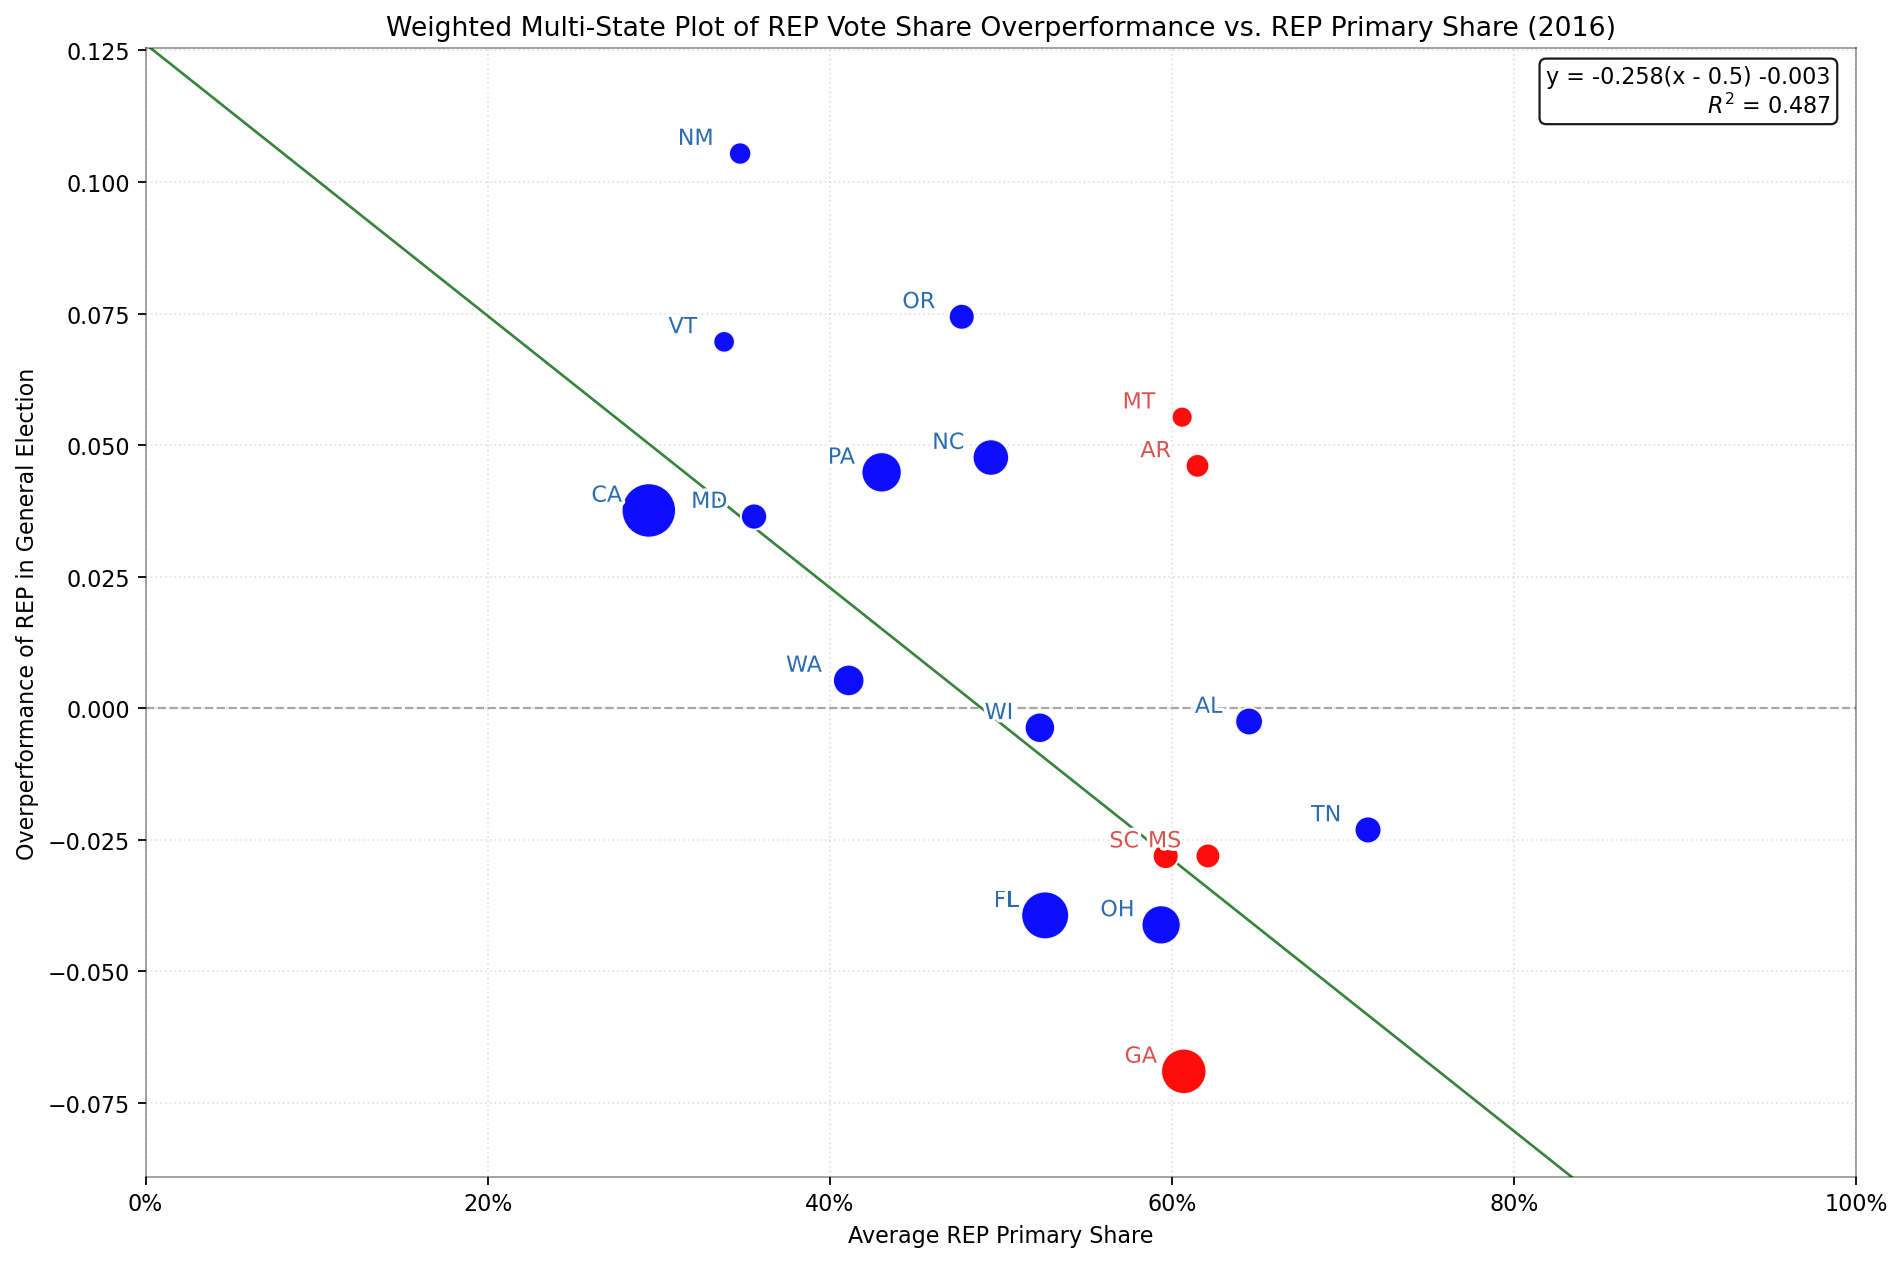

In [30]:
# Multistate REP Overperformance vs REP Primary Share
dt2_subset["w_common"] = dt2_subset["rep_general_total"] + dt2_subset["dem_general_total"]

# Aggregate to one point per state (means for x,g; total votes for bubble size)
agg = (
    dt2_subset.groupby("state", as_index=False)
       .apply(lambda g: pd.Series({
            "x": g["rep_primary_share"].mean(),                         # avg primary REP share
            "g": g["rep_general_share"].mean(),                         # avg general REP share
            "g_w": np.average(g["rep_general_share"], weights=g["w_common"]),  # weighted gen share (for winner color)
            "w": g["w_common"].sum()                                    # total general votes
       }))
       .reset_index(drop=True)
)

# Overperformance AFTER aggregation
agg["y"] = agg["g"] - agg["x"]

# Drop any rows with non-finite x, y, or w
agg = agg.replace([np.inf, -np.inf], np.nan)
agg = agg.dropna(subset=["x", "y", "w"])

# Now extract clean arrays
x = agg["x"].to_numpy()
y = agg["y"].to_numpy()
w = agg["w"].to_numpy()

# Weighted LS fit (by vote totals)
xbar = np.average(x, weights=w)
ybar = np.average(y, weights=w)
m = np.sum(w * (x - xbar) * (y - ybar)) / np.sum(w * (x - xbar) ** 2)
b = ybar - m * xbar

# Weighted R^2
yhat = m * x + b
sst = np.sum(w * (y - ybar) ** 2)
sse = np.sum(w * (y - yhat) ** 2)
r2 = 1 - sse / sst if sst > 0 else np.nan

# Display form centered at 0.50
x0 = 0.50
c_center = b + m * x0   # y = m (x - 0.50) + c_center

# Bubble sizes and colors (red = REP wins general; blue = DEM wins)
sizes  = np.interp(agg["w"], (agg["w"].min(), agg["w"].max()), (90, 600))
colors = np.where(agg["g_w"] >= 0.5, "red", "blue")  

# Plot 
fig, ax = plt.subplots(figsize=(12, 8), dpi=160)

# Scatter
ax.scatter(agg["x"], agg["y"], s=sizes, c=colors,
           alpha=0.95, edgecolors="white", linewidths=0.9, zorder=3)

# Labels — down-left; color to match dot; white halo for readability
for _, r in agg.iterrows():
    ax.annotate(
        r["state"], (r["x"], r["y"]),
        xytext=(-12, 12), textcoords="offset points",
        ha="right", va="top", fontsize=10, color="#d9534f" if r["g_w"] >= 0.5 else "#2b6cb0",
        path_effects=[pe.withStroke(linewidth=3, foreground="white")]
    )

# Regression line (green, thin)
xs = np.linspace(0.0, 1.0, 300)
ax.plot(xs, m * xs + b, color="#2e7d32", lw=1.2, alpha=0.95, zorder=2)

# Zero baseline only
ax.axhline(0, ls="--", lw=1, color="gray", alpha=0.7, zorder=1)

# Cosmetics similar to the reference
ax.set_xlim(0, 1)
ypad = max(0.02, 0.1 * (y.max() - y.min()))
ax.set_ylim(y.min() - ypad, y.max() + ypad)
ax.set_xlabel("Average REP Primary Share")
ax.set_ylabel("Overperformance of REP in General Election")
ax.set_title("Weighted Multi-State Plot of REP Vote Share Overperformance vs. REP Primary Share (2016)")
ax.grid(True, linestyle=":", alpha=0.35)
ax.set_xticks(np.linspace(0, 1, 6))
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
for spine in ax.spines.values():
    spine.set_alpha(0.4)

# Equation + R^2 box (top-right corner)
eq_txt = f"y = {m:+.3f}(x - {x0:.1f}) {c_center:+.3f}\n$R^2$ = {r2:.3f}"
ax.text(0.985, 0.985, eq_txt, transform=ax.transAxes,
        ha="right", va="top",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", alpha=0.9),
        fontsize=10)

plt.tight_layout()
plt.show()

### 3.3. 2020 Presidential Election

/var/folders/10/yh5g9ksn5fb_2pzdwtzd2tlh0000gn/T/ipykernel_22721/4294433330.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


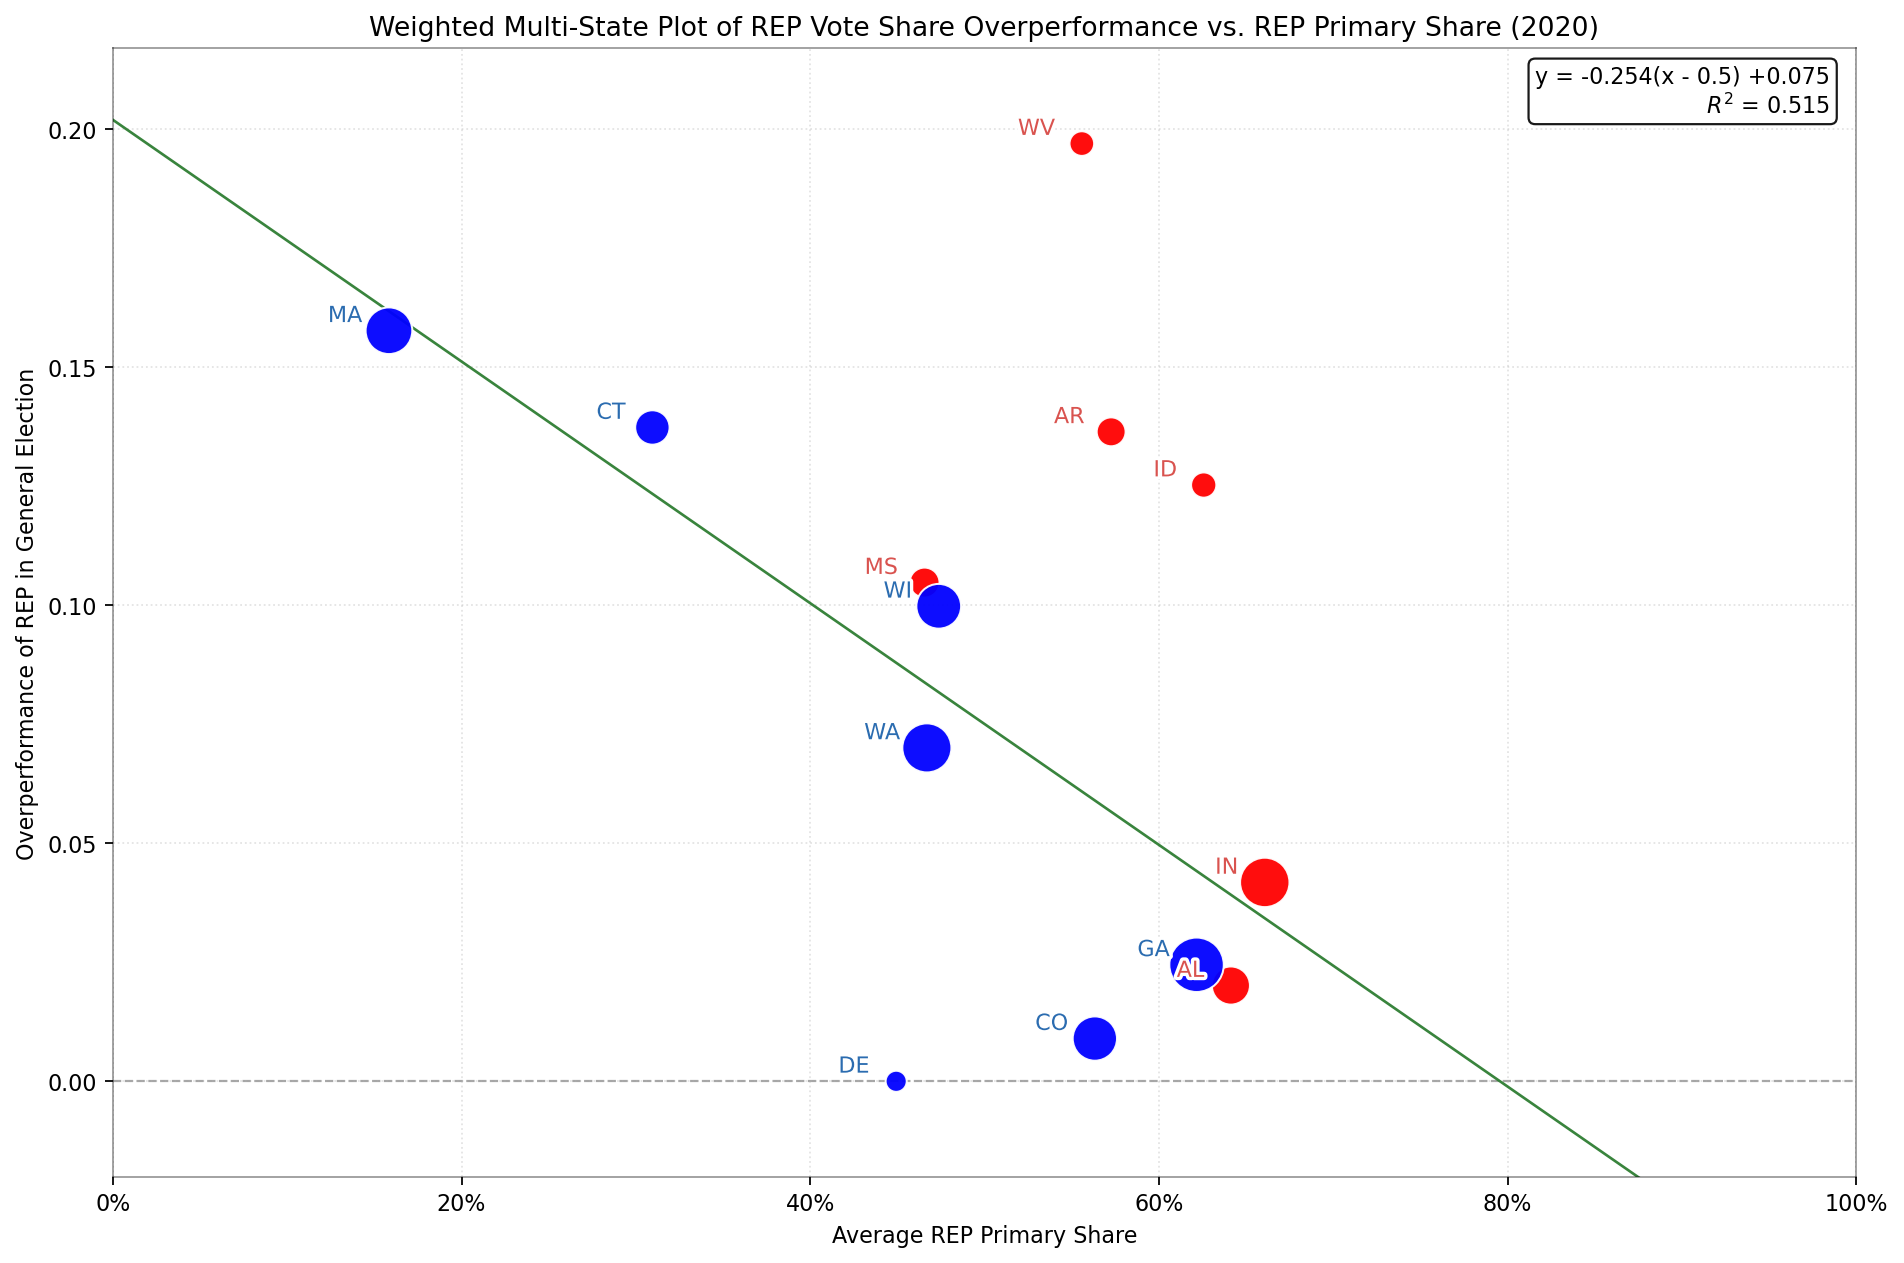

In [10]:
# Multistate REP Overperformance vs REP Primary Share
dt3_subset["w_common"] = dt3_subset["rep_general_total"] + dt3_subset["dem_general_total"]

# Aggregate to one point per state (means for x,g; total votes for bubble size)
agg = (
    dt3_subset.groupby("state", as_index=False)
       .apply(lambda g: pd.Series({
            "x": g["rep_primary_share"].mean(),                         # avg primary REP share
            "g": g["rep_general_share"].mean(),                         # avg general REP share
            "g_w": np.average(g["rep_general_share"], weights=g["w_common"]),  # weighted gen share (for winner color)
            "w": g["w_common"].sum()                                    # total general votes
       }))
       .reset_index(drop=True)
)

# Overperformance AFTER aggregation
agg["y"] = agg["g"] - agg["x"]

# Drop any rows with non-finite x, y, or w
agg = agg.replace([np.inf, -np.inf], np.nan)
agg = agg.dropna(subset=["x", "y", "w"])

# Now extract clean arrays
x = agg["x"].to_numpy()
y = agg["y"].to_numpy()
w = agg["w"].to_numpy()

# Weighted LS fit (by vote totals)
xbar = np.average(x, weights=w)
ybar = np.average(y, weights=w)
m = np.sum(w * (x - xbar) * (y - ybar)) / np.sum(w * (x - xbar) ** 2)
b = ybar - m * xbar

# Weighted R^2
yhat = m * x + b
sst = np.sum(w * (y - ybar) ** 2)
sse = np.sum(w * (y - yhat) ** 2)
r2 = 1 - sse / sst if sst > 0 else np.nan

# Display form centered at 0.50
x0 = 0.50
c_center = b + m * x0   # y = m (x - 0.50) + c_center

# Bubble sizes and colors (red = REP wins general; blue = DEM wins)
sizes  = np.interp(agg["w"], (agg["w"].min(), agg["w"].max()), (90, 600))
colors = np.where(agg["g_w"] >= 0.5, "red", "blue")  

# Plot 
fig, ax = plt.subplots(figsize=(12, 8), dpi=160)

# Scatter
ax.scatter(agg["x"], agg["y"], s=sizes, c=colors,
           alpha=0.95, edgecolors="white", linewidths=0.9, zorder=3)

# Labels — down-left; color to match dot; white halo for readability
for _, r in agg.iterrows():
    ax.annotate(
        r["state"], (r["x"], r["y"]),
        xytext=(-12, 12), textcoords="offset points",
        ha="right", va="top", fontsize=10, color="#d9534f" if r["g_w"] >= 0.5 else "#2b6cb0",
        path_effects=[pe.withStroke(linewidth=3, foreground="white")]
    )

# Regression line (green, thin)
xs = np.linspace(0.0, 1.0, 300)
ax.plot(xs, m * xs + b, color="#2e7d32", lw=1.2, alpha=0.95, zorder=2)

# Zero baseline only
ax.axhline(0, ls="--", lw=1, color="gray", alpha=0.7, zorder=1)

# Cosmetics similar to the reference
ax.set_xlim(0, 1)
ypad = max(0.02, 0.1 * (y.max() - y.min()))
ax.set_ylim(y.min() - ypad, y.max() + ypad)
ax.set_xlabel("Average REP Primary Share")
ax.set_ylabel("Overperformance of REP in General Election")
ax.set_title("Weighted Multi-State Plot of REP Vote Share Overperformance vs. REP Primary Share (2020)")
ax.grid(True, linestyle=":", alpha=0.35)
ax.set_xticks(np.linspace(0, 1, 6))
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
for spine in ax.spines.values():
    spine.set_alpha(0.4)

# Equation + R^2 box (top-right corner)
eq_txt = f"y = {m:+.3f}(x - {x0:.1f}) {c_center:+.3f}\n$R^2$ = {r2:.3f}"
ax.text(0.985, 0.985, eq_txt, transform=ax.transAxes,
        ha="right", va="top",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", alpha=0.9),
        fontsize=10)

plt.tight_layout()
plt.show()